In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import glob
import os

# Folder input
path = "/content/drive/My Drive/Colab Notebooks/DATASET/"

# Folder output
out_path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetclean/"

kelas_durasi = {
    "diamjatuh": 30,
    "jalanjatuh": 30,
    "jalan": 60,
    "diam": 75
}

freq = 200

files = glob.glob(path + "*.csv")

for file in files:

    filename = os.path.basename(file).lower()

    ditemukan = False

    for kelas, durasi in kelas_durasi.items():

        if kelas in filename:

            ditemukan = True

            max_rows = durasi * freq

            df = pd.read_csv(file)

            # hapus kolom tidak perlu
            df = df.drop(
                columns=["seq","timestamp","timestamp_ms","label"],
                errors="ignore"
            )

            asli = len(df)

            # potong sesuai target
            df = df.iloc[:max_rows]

            if asli < max_rows:
                print(f"WARNING {filename}: kurang ({asli}/{max_rows})")

            # simpan ke folder baru
            out = out_path + filename.replace(".csv","_clean.csv")

            df.to_csv(out, index=False)

            print(f"{filename} -> {len(df)} baris ({kelas})")

            break

    if not ditemukan:
        print("SKIP:", filename)

diam1.csv -> 15000 baris (diam)
diamjatuh10.csv -> 6000 baris (diamjatuh)
jalanjatuh1.csv -> 6000 baris (jalanjatuh)
jalanjatuh2.csv -> 6000 baris (jalanjatuh)
jalanjatuh3.csv -> 6000 baris (jalanjatuh)
jalanjatuh4.csv -> 6000 baris (jalanjatuh)
jalanjatuh5.csv -> 6000 baris (jalanjatuh)
jalanjatuh6.csv -> 6000 baris (jalanjatuh)
jalanjatuh7.csv -> 6000 baris (jalanjatuh)
jalanjatuh8.csv -> 6000 baris (jalanjatuh)
jalanjatuh9.csv -> 6000 baris (jalanjatuh)
jalanjatuh10.csv -> 6000 baris (jalanjatuh)
diam2.csv -> 15000 baris (diam)
diam3.csv -> 15000 baris (diam)
diam4.csv -> 15000 baris (diam)
jalan1.csv -> 12000 baris (jalan)
jalan2.csv -> 12000 baris (jalan)
jalan3.csv -> 12000 baris (jalan)
jalan4.csv -> 12000 baris (jalan)
jalan5.csv -> 12000 baris (jalan)
diamjatuh1.csv -> 6000 baris (diamjatuh)
diamjatuh2.csv -> 6000 baris (diamjatuh)
diamjatuh3.csv -> 6000 baris (diamjatuh)
diamjatuh4.csv -> 6000 baris (diamjatuh)
diamjatuh5.csv -> 6000 baris (diamjatuh)
diamjatuh6.csv -> 6000 b

In [ ]:
import re

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetclean/"
out_path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"

os.makedirs(out_path, exist_ok=True)

kelas_patterns = {
    "diam": r"^diam\d+_clean\.csv$",
    "jalan": r"^jalan\d+_clean\.csv$",
    "diamjatuh": r"^diamjatuh\d+_clean\.csv$",
    "jalanjatuh": r"^jalanjatuh\d+_clean\.csv$"
}

all_files = os.listdir(path)

for kelas, pattern in kelas_patterns.items():

    selected = []

    for file in all_files:
        if re.match(pattern, file):
            selected.append(file)

    selected.sort()

    gabung = []

    for file in selected:
        df = pd.read_csv(path + file)
        gabung.append(df)

    final_df = pd.concat(gabung, ignore_index=True)

    final_df.to_csv(out_path + kelas + ".csv", index=False)

    print(kelas, "->", len(final_df), "baris")

diam -> 60000 baris
jalan -> 60000 baris
diamjatuh -> 60000 baris
jalanjatuh -> 60000 baris


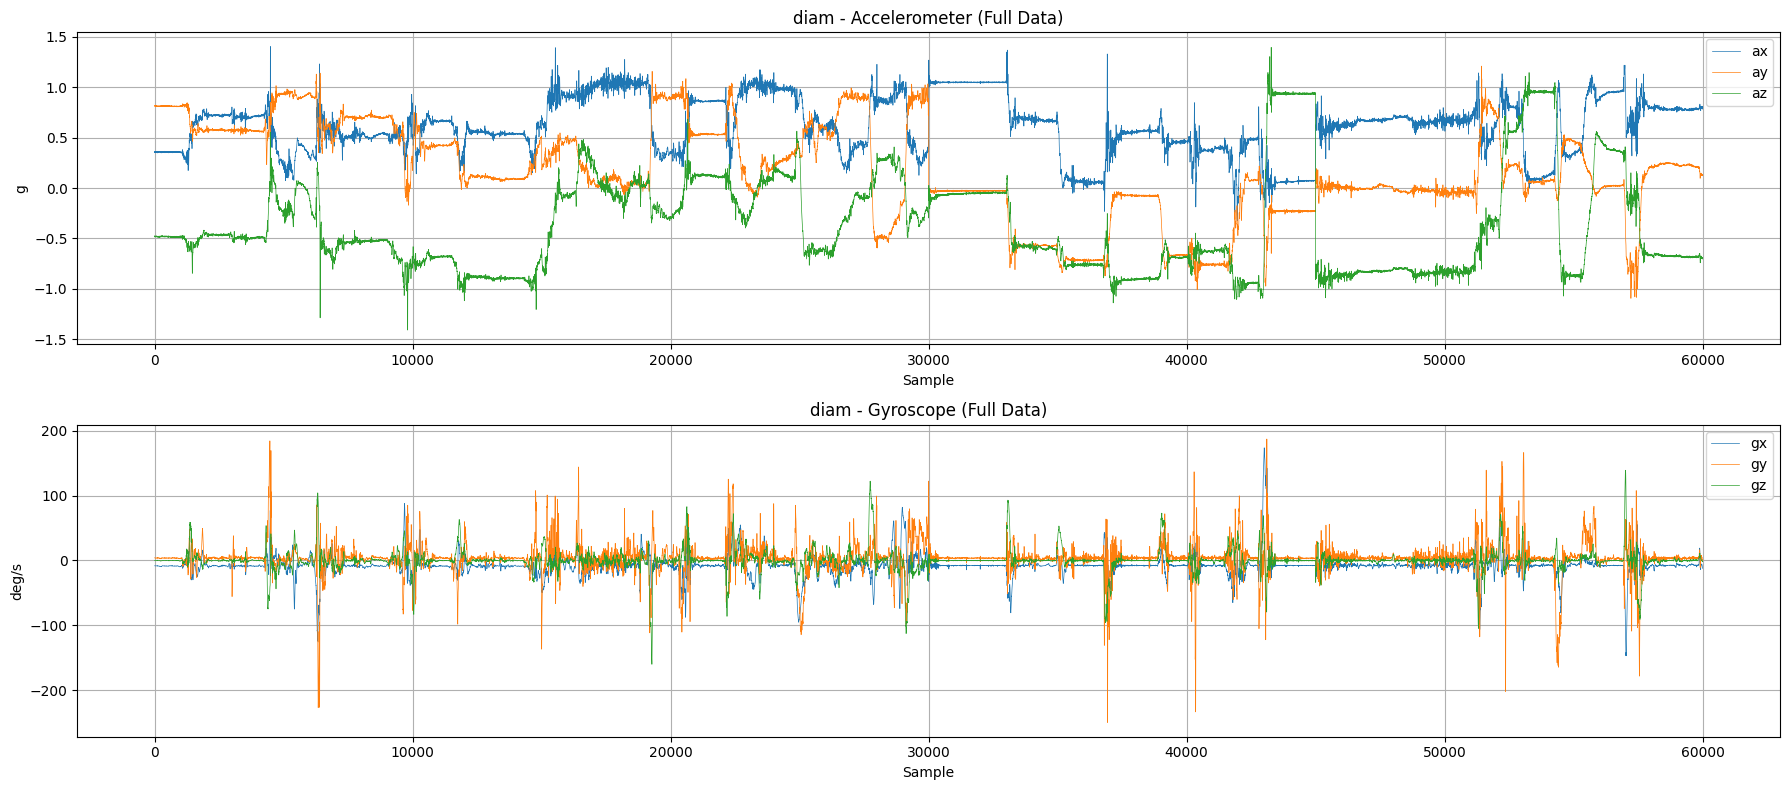

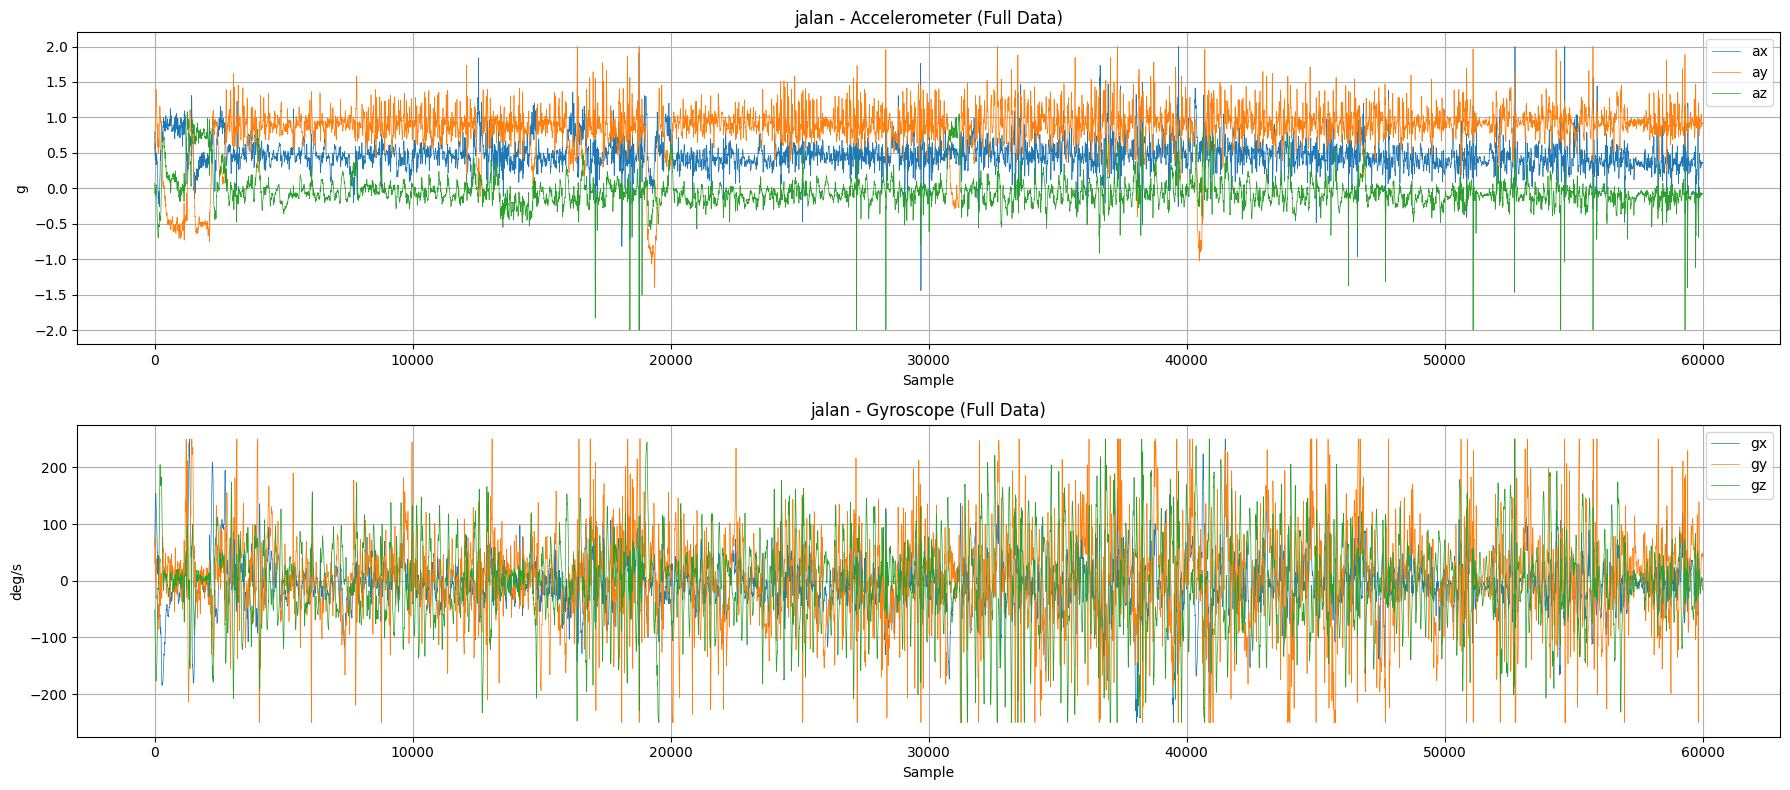

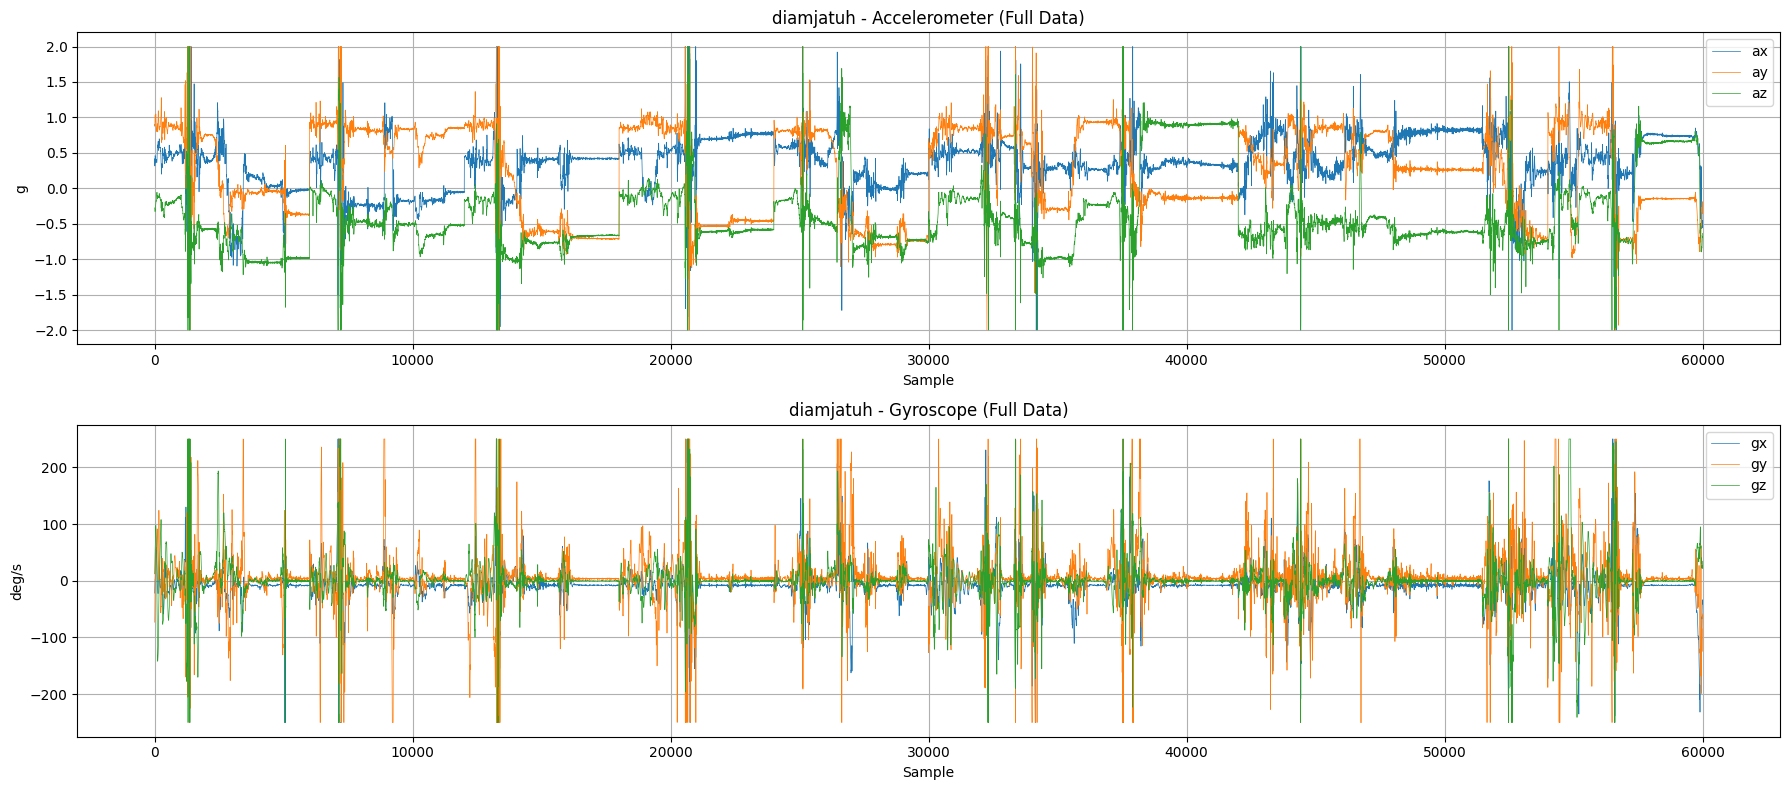

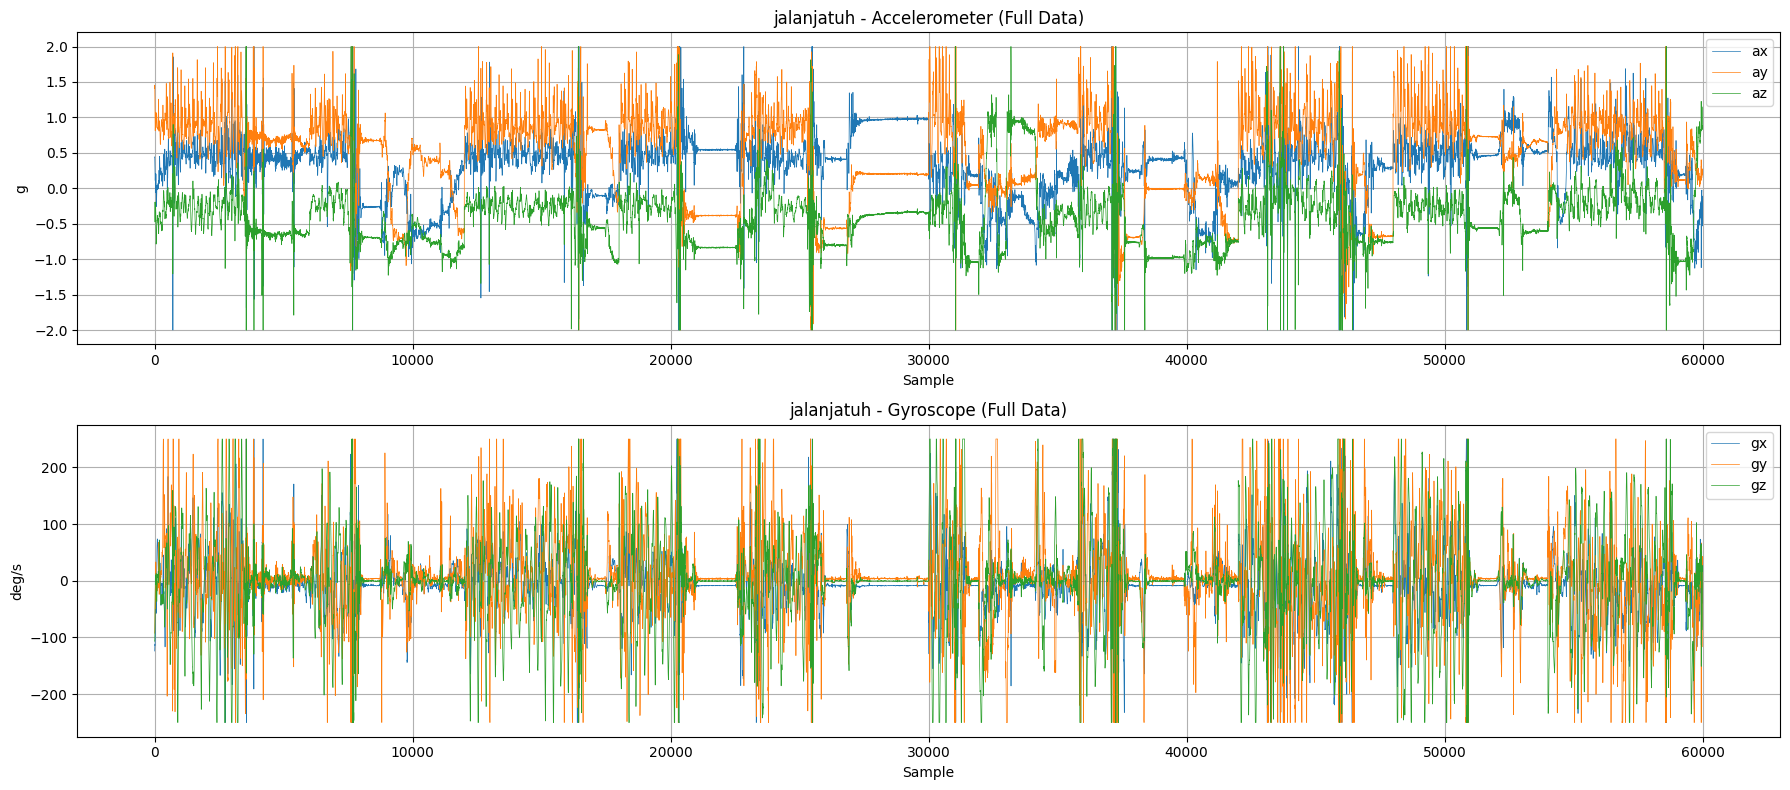

In [ ]:
import matplotlib.pyplot as plt

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"

kelas = ["diam","jalan","diamjatuh","jalanjatuh"]

for k in kelas:

    df = pd.read_csv(path + k + ".csv")

    fig, ax = plt.subplots(2,1, figsize=(18,8))

    # Accelerometer
    ax[0].plot(df["ax"], label="ax", linewidth=0.5)
    ax[0].plot(df["ay"], label="ay", linewidth=0.5)
    ax[0].plot(df["az"], label="az", linewidth=0.5)

    ax[0].set_title(k + " - Accelerometer (Full Data)")
    ax[0].set_xlabel("Sample")
    ax[0].set_ylabel("g")
    ax[0].legend()
    ax[0].grid(True)

    # Gyroscope
    ax[1].plot(df["gx"], label="gx", linewidth=0.5)
    ax[1].plot(df["gy"], label="gy", linewidth=0.5)
    ax[1].plot(df["gz"], label="gz", linewidth=0.5)

    ax[1].set_title(k + " - Gyroscope (Full Data)")
    ax[1].set_xlabel("Sample")
    ax[1].set_ylabel("deg/s")
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()


KELAS : DIAM
Jumlah Data : 60000
ax -> Dominant Freq = 0.098 Hz | Power = 0.11888
ay -> Dominant Freq = 0.098 Hz | Power = 0.24551
az -> Dominant Freq = 0.098 Hz | Power = 0.39435
gx -> Dominant Freq = 0.195 Hz | Power = 454.73914
gy -> Dominant Freq = 0.098 Hz | Power = 573.28377
gz -> Dominant Freq = 0.195 Hz | Power = 452.49095


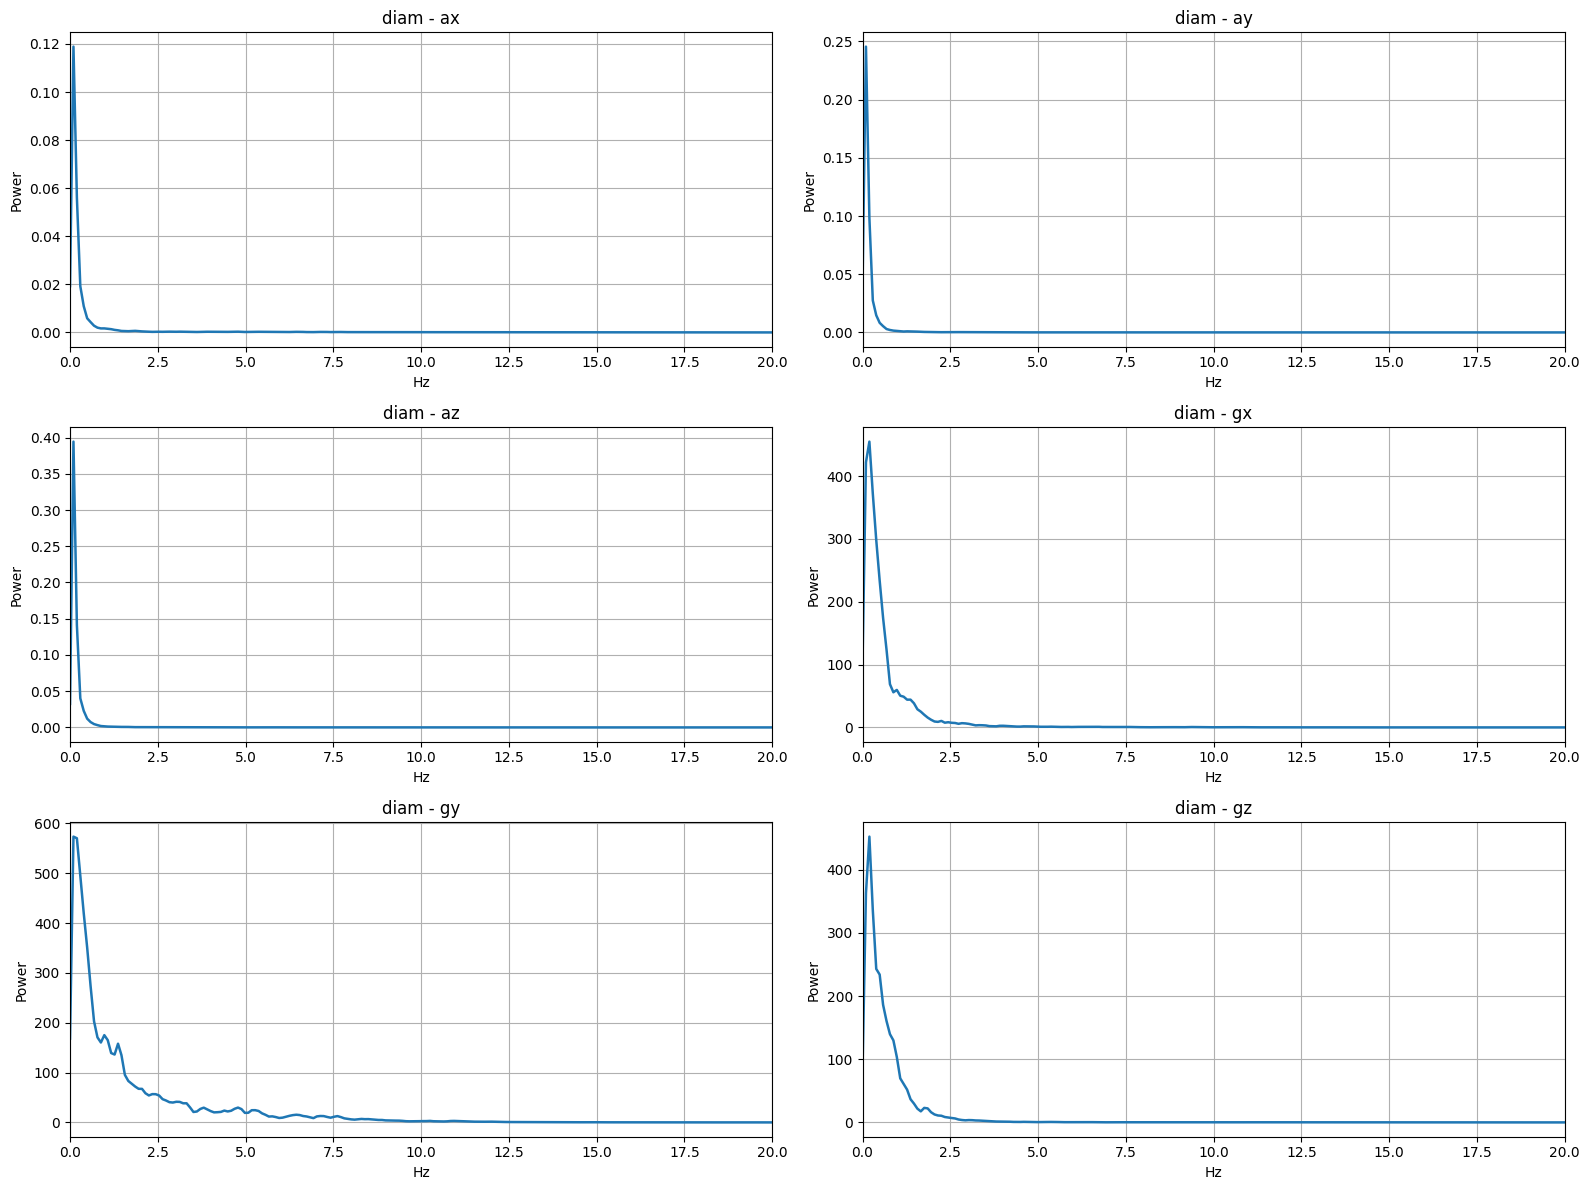


KELAS : JALAN
Jumlah Data : 60000
ax -> Dominant Freq = 0.098 Hz | Power = 0.03431
ay -> Dominant Freq = 0.098 Hz | Power = 0.15033
az -> Dominant Freq = 0.098 Hz | Power = 0.05590
gx -> Dominant Freq = 0.098 Hz | Power = 2031.53359
gy -> Dominant Freq = 0.098 Hz | Power = 6786.37245
gz -> Dominant Freq = 0.684 Hz | Power = 10121.14204


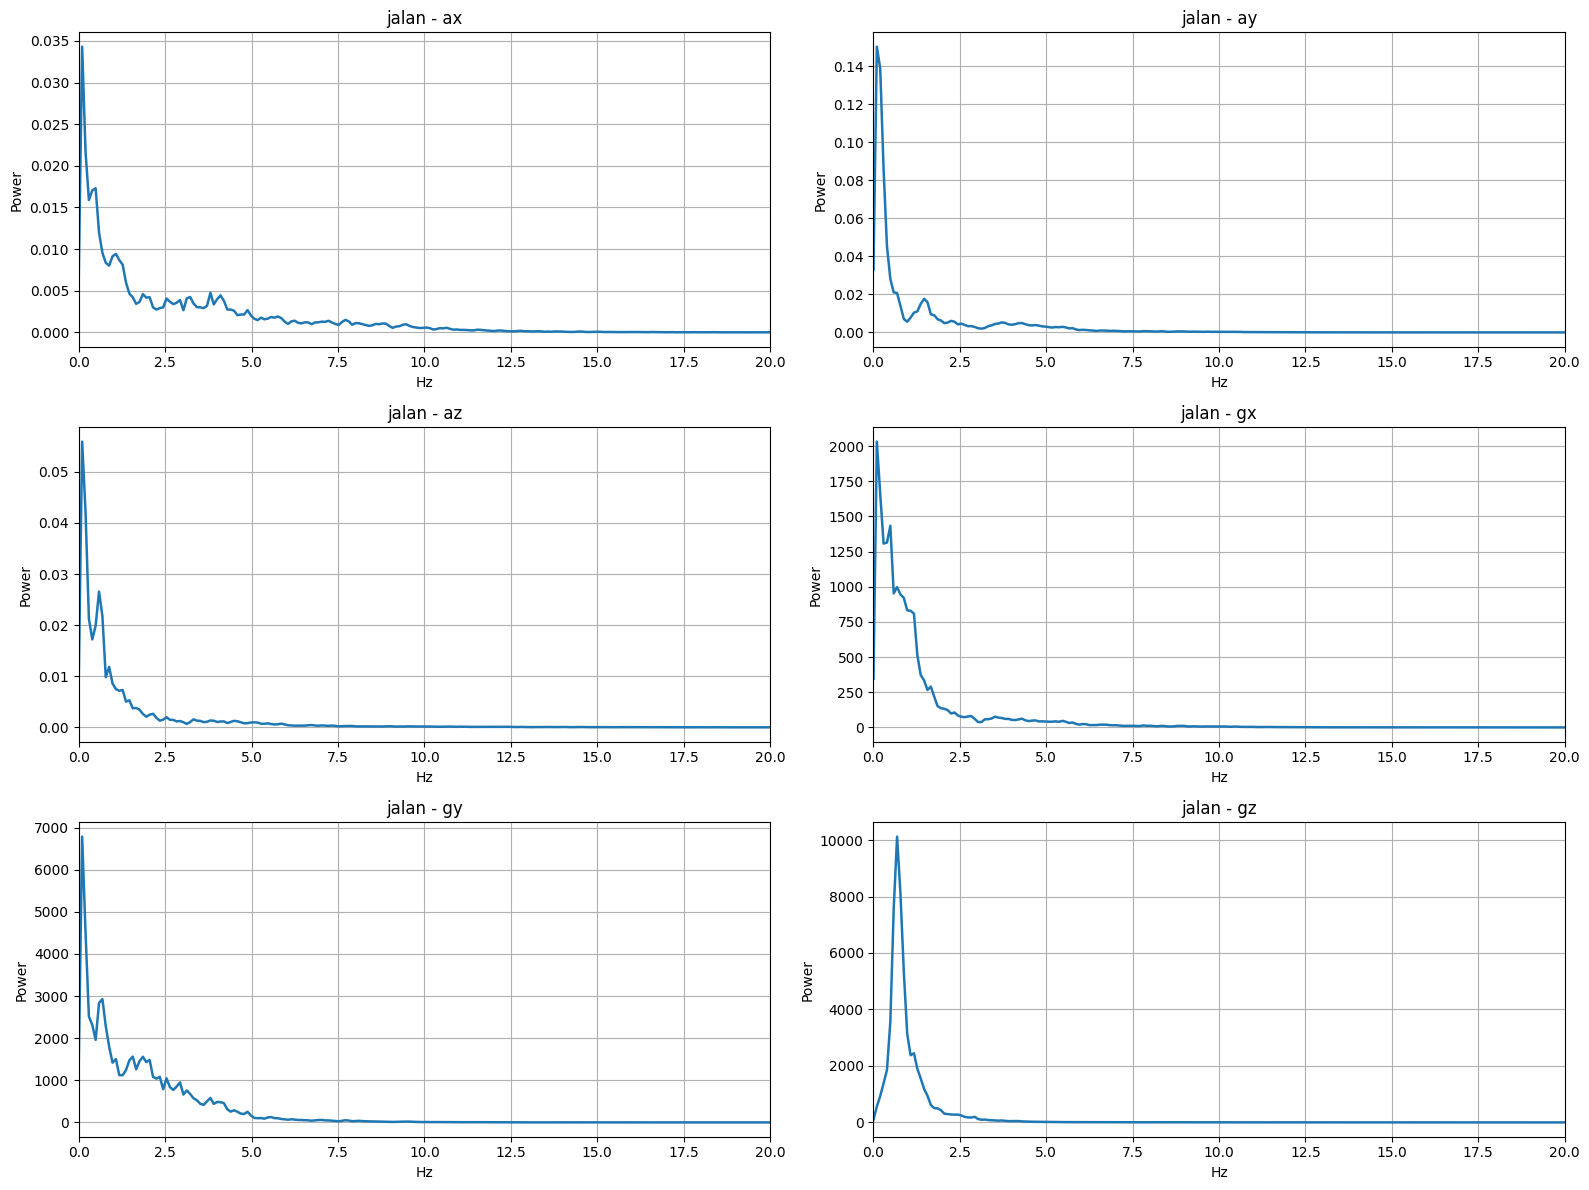


KELAS : DIAMJATUH
Jumlah Data : 60000
ax -> Dominant Freq = 0.098 Hz | Power = 0.18839
ay -> Dominant Freq = 0.098 Hz | Power = 0.54905
az -> Dominant Freq = 0.098 Hz | Power = 0.31990
gx -> Dominant Freq = 0.488 Hz | Power = 630.15932
gy -> Dominant Freq = 0.488 Hz | Power = 1252.57009
gz -> Dominant Freq = 0.293 Hz | Power = 850.94885


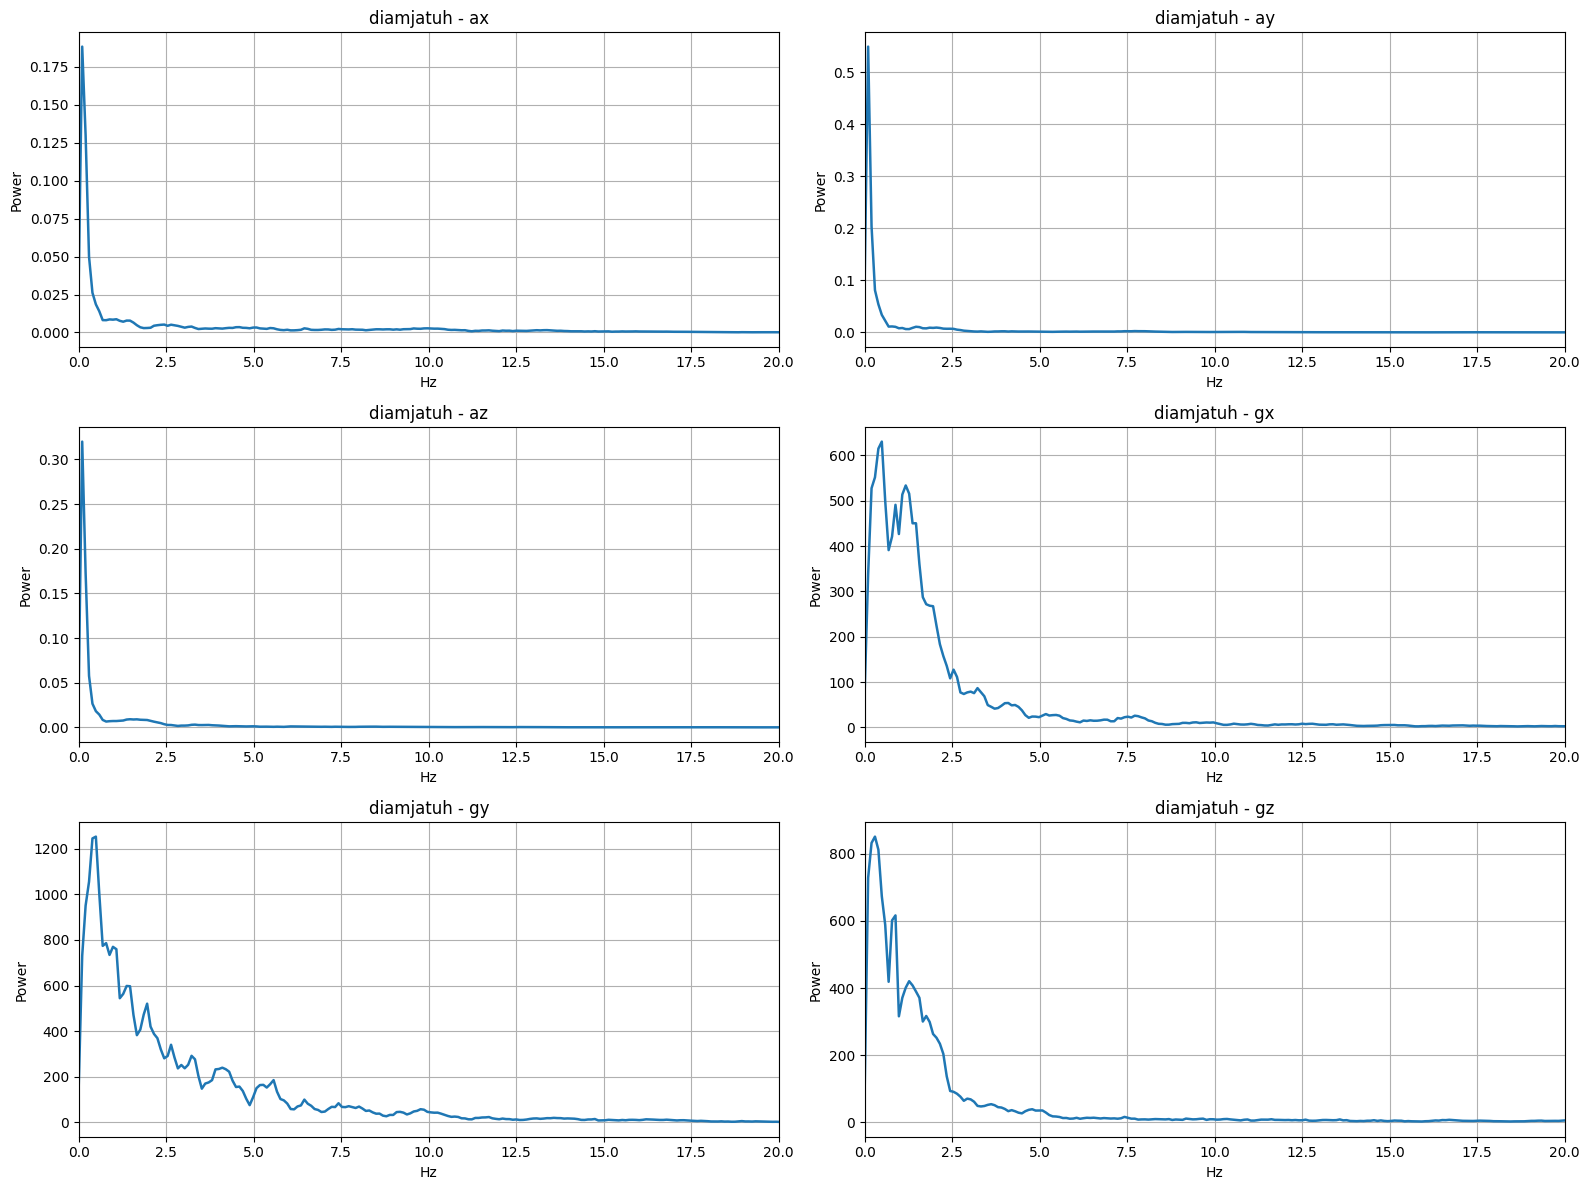


KELAS : JALANJATUH
Jumlah Data : 60000
ax -> Dominant Freq = 0.098 Hz | Power = 0.18376
ay -> Dominant Freq = 0.098 Hz | Power = 0.56259
az -> Dominant Freq = 0.098 Hz | Power = 0.22573
gx -> Dominant Freq = 0.684 Hz | Power = 3170.41693
gy -> Dominant Freq = 0.684 Hz | Power = 4558.30023
gz -> Dominant Freq = 0.684 Hz | Power = 12556.19608


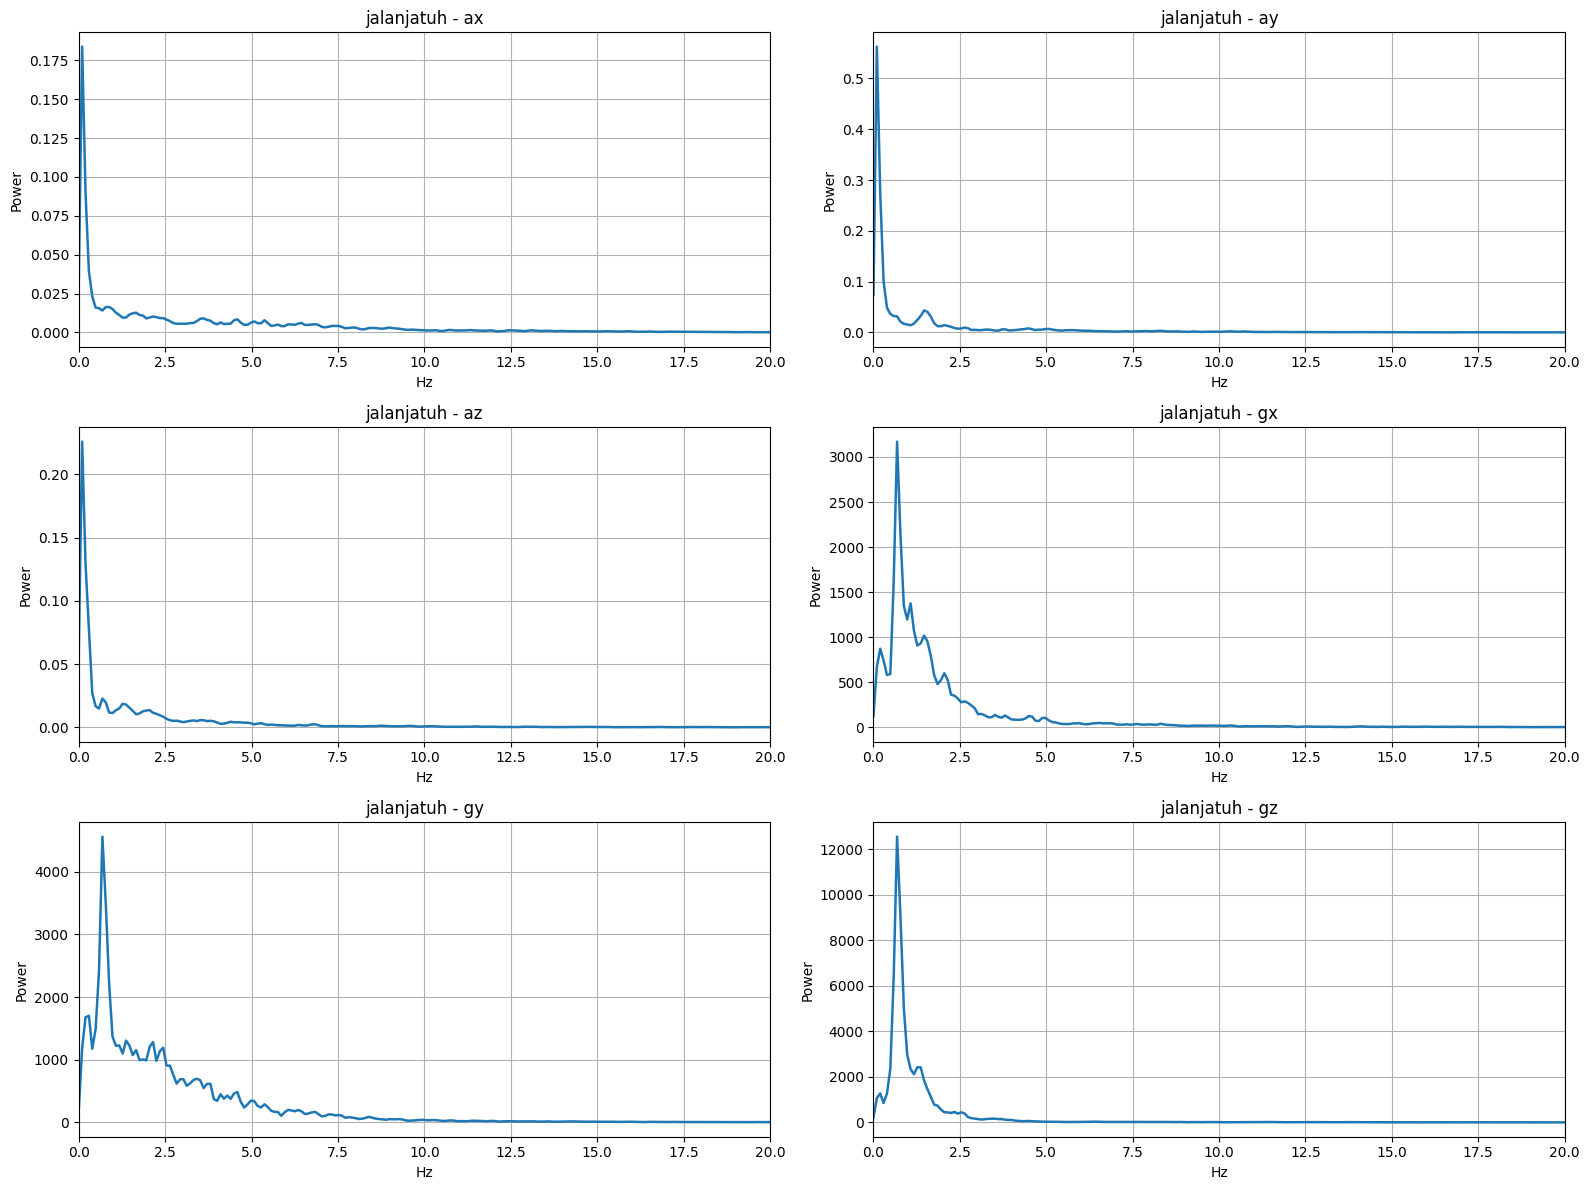

In [ ]:
# PSA
# Dataset MPU6050

import matplotlib.pyplot as plt
from scipy.signal import welch

# KONFIGURASI

fs = 200   # sampling frequency (Hz)

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"

kelas_list = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

channels = [
    "ax","ay","az",
    "gx","gy","gz"
]

# LOOP PER KELAS

for kelas in kelas_list:

    file = path + kelas + ".csv"

    df = pd.read_csv(file)

    print("KELAS :", kelas.upper())
    print("Jumlah Data :", len(df))

    # Plot PSD 6 Channel

    fig, axs = plt.subplots(3,2, figsize=(16,12))
    axs = axs.ravel()

    for i, ch in enumerate(channels):

        signal = df[ch].values

        # Welch PSD
        freq, psd = welch(
            signal,
            fs=fs,
            nperseg=2048
        )

        # Cari frekuensi dominan
        idx = np.argmax(psd[1:]) + 1   # skip 0 Hz
        dom_freq = freq[idx]
        dom_power = psd[idx]

        print(f"{ch:>2} -> Dominant Freq = {dom_freq:.3f} Hz | Power = {dom_power:.5f}")

        axs[i].plot(freq, psd, linewidth=1.8)
        axs[i].set_title(f"{kelas} - {ch}")
        axs[i].set_xlabel("Hz")
        axs[i].set_ylabel("Power")
        axs[i].set_xlim(0, 20)
        axs[i].grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
# PREPROCESSING - WINDOW 200


import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# KONFIGURASI

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"

save_path = "/content/drive/My Drive/Colab Notebooks/datasetready_200/"
os.makedirs(save_path, exist_ok=True)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 200
stride = 200     # tanpa overlap

# LIST DATA

X = []
y = []


# WINDOWING

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df.values   # 6 kolom sensor

    total_window = 0

    for i in range(0, len(data) - window + 1, stride):

        segmen = data[i:i+window]

        X.append(segmen)
        y.append(label)

        total_window += 1

    print("Window:", total_window)

# NUMPY ARRAY

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("\n================================")
print("Shape X :", X.shape)
print("Shape y :", y.shape)
print("================================")

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)


# STANDARDIZATION

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(-1, fitur)
X_test_2d  = X_test.reshape(-1, fitur)

# fit hanya train
scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d)
X_test_scaled  = scaler.transform(X_test_2d)

# balik shape
X_train = X_train_scaled.reshape(
    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(
    X_test.shape[0],
    timestep,
    fitur
)

# SAVE DATASET

np.save(save_path + "X_train.npy", X_train)
np.save(save_path + "X_test.npy", X_test)
np.save(save_path + "y_train.npy", y_train)
np.save(save_path + "y_test.npy", y_test)

print("\n================================")
print("Dataset Window 200 Siap CNN")
print("Saved to:", save_path)
print("================================")

Processing: diam
Window: 300
Processing: jalan
Window: 300
Processing: diamjatuh
Window: 300
Processing: jalanjatuh
Window: 300

Shape X : (1200, 200, 6)
Shape y : (1200,)
Train : (960, 200, 6)
Test  : (240, 200, 6)

Dataset Window 200 Siap CNN
Saved to: /content/drive/My Drive/Colab Notebooks/datasetready_200/


Train : (960, 200, 6)
Test  : (240, 200, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 196, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 196, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 96, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,276 (1.60 MB)

...


Epoch 2: finished saving model to best_model_window200.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5664 - loss: 1.2826 - val_accuracy: 0.5677 - val_loss: 1.1238 - learning_rate: 0.0010
Epoch 3/100
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6338 - loss: 1.0705
Epoch 3: val_accuracy did not improve from 0.56771
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6276 - loss: 1.1130 - val_accuracy: 0.4844 - val_loss: 1.1230 - learning_rate: 0.0010
Epoch 4/100
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6258 - loss: 0.9618
Epoch 4: val_accuracy did not improve from 0.56771
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6302 - loss: 0.9696 - val_accuracy: 0.5469 - val_loss: 1.0496 - learning_rate: 0.0010
Epoch 5/100
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6637 - loss: 0.8105
Epoch 5: val_accuracy improved from 0.56771 to 0.59375, saving model to best_model_window200.h5



Epoch 5: finished saving model to best_model_window200.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6562 - loss: 0.8618 - val_accuracy: 0.5938 - val_loss: 1.0039 - learning_rate: 0.0010
Epoch 6/100
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6875 - loss: 0.7311
Epoch 6: val_accuracy did not improve from 0.59375
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6927 - loss: 0.7632 - val_accuracy: 0.5729 - val_loss: 0.9842 - learning_rate: 0.0010
Epoch 7/100
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7138 - loss: 0.6883
Epoch 7: val_accuracy did not improve from 0.59375
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7044 - loss: 0.7261 - val_accuracy: 0.5677 - val_loss: 0.9801 - learning_rate: 0.0010
Epoch 8/100
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6761 - loss: 0.7190
Epoch 8: val_accuracy did not improve from 0.59375
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7070 - loss: 0.7028 - val_accuracy: 0.5781 - val_loss: 1


Epoch 10: finished saving model to best_model_window200.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7057 - loss: 0.7043 - val_accuracy: 0.6302 - val_loss: 0.9217 - learning_rate: 0.0010
Epoch 11/100
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7802 - loss: 0.5174
Epoch 11: val_accuracy did not improve from 0.63021
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7643 - loss: 0.5478 - val_accuracy: 0.5938 - val_loss: 0.9347 - learning_rate: 0.0010
Epoch 12/100
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7836 - loss: 0.5320
Epoch 12: val_accuracy improved from 0.63021 to 0.64583, saving model to best_model_window200.h5



Epoch 12: finished saving model to best_model_window200.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7708 - loss: 0.5426 - val_accuracy: 0.6458 - val_loss: 0.9569 - learning_rate: 0.0010
Epoch 13/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8013 - loss: 0.4738
Epoch 13: val_accuracy did not improve from 0.64583
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7826 - loss: 0.5311 - val_accuracy: 0.6094 - val_loss: 0.9420 - learning_rate: 0.0010
Epoch 14/100
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7721 - loss: 0.5560
Epoch 14: val_accuracy did not improve from 0.64583
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7773 - loss: 0.5440 - val_accuracy: 0.6406 - val_loss: 1.0496 - learning_rate: 0.0010
Epoch 15/100
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7887 - loss: 0.5056
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: val_accuracy did not improve from 0.64583
24/24 ━━━━━━━━━━━━━━━━━━━


Epoch 16: finished saving model to best_model_window200.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8047 - loss: 0.4394 - val_accuracy: 0.6823 - val_loss: 0.9203 - learning_rate: 5.0000e-04
Epoch 17/100
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8300 - loss: 0.4178
Epoch 17: val_accuracy did not improve from 0.68229
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8203 - loss: 0.4269 - val_accuracy: 0.6562 - val_loss: 0.9527 - learning_rate: 5.0000e-04
Epoch 18/100
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8573 - loss: 0.3459
Epoch 18: val_accuracy did not improve from 0.68229
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8503 - loss: 0.3906 - val_accuracy: 0.6562 - val_loss: 0.9186 - learning_rate: 5.0000e-04
Epoch 19/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8348 - loss: 0.3542
Epoch 19: val_accuracy did not improve from 0.68229
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8490 - loss: 0.3527 - val_accuracy: 0

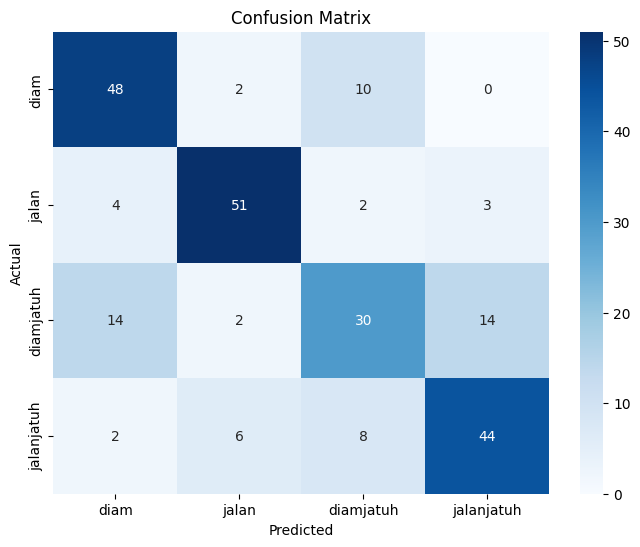

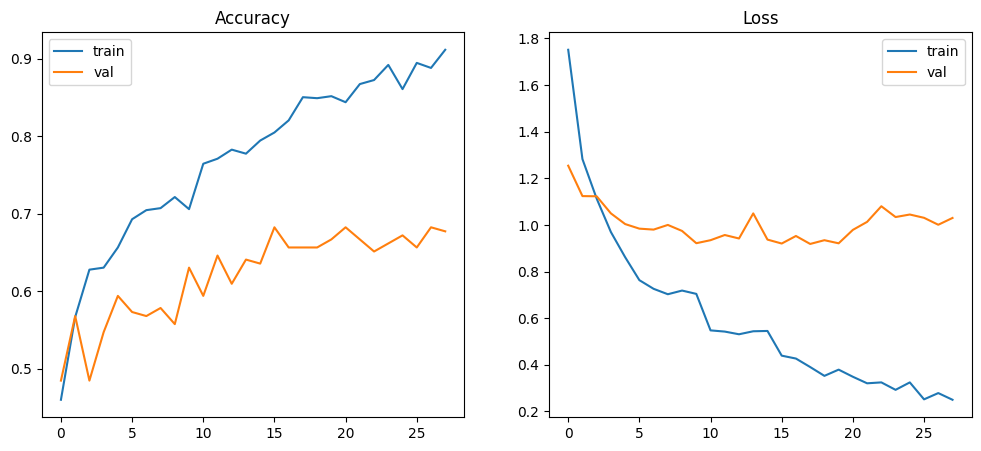

In [ ]:
# TRAINING - DATASET WINDOW 200


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

# LOAD DATASET


path = "/content/drive/My Drive/Colab Notebooks/datasetready_200/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")
y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# MODEL CNN 1D

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(200,6)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

# COMPILE

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# CALLBACKS

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_window200.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# TRAINING

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,
    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

# EVALUASI

loss, acc = model.evaluate(X_test, y_test)

print("\n=================================")
print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))
print("=================================")

# PREDIKSI

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# CLASSIFICATION REPORT

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=kelas))

# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# GRAFIK TRAINING

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING FINAL - WINDOW 300

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# KONFIGURASI

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"

save_path = "/content/drive/My Drive/Colab Notebooks/datasetready_300/"
os.makedirs(save_path, exist_ok=True)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 300
stride = 300      # tanpa overlap


# LIST DATA

X = []
y = []


# WINDOWING

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df.values   # 6 kolom sensor

    total_window = 0

    for i in range(0, len(data) - window + 1, stride):

        segmen = data[i:i+window]

        X.append(segmen)
        y.append(label)

        total_window += 1

    print("Jumlah Window:", total_window)

# NUMPY ARRAY

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("\n================================")
print("Shape X :", X.shape)
print("Shape y :", y.shape)
print("================================")

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# STANDARDIZATION

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(-1, fitur)
X_test_2d  = X_test.reshape(-1, fitur)

# fit hanya train
scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d)
X_test_scaled  = scaler.transform(X_test_2d)

# balik shape
X_train = X_train_scaled.reshape(
    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(
    X_test.shape[0],
    timestep,
    fitur
)
# SAVE DATASET

np.save(save_path + "X_train.npy", X_train)
np.save(save_path + "X_test.npy", X_test)
np.save(save_path + "y_train.npy", y_train)
np.save(save_path + "y_test.npy", y_test)

print("Dataset Window 300 Siap CNN")
print("Saved to:", save_path)

Processing: diam
Jumlah Window: 200
Processing: jalan
Jumlah Window: 200
Processing: diamjatuh
Jumlah Window: 200
Processing: jalanjatuh
Jumlah Window: 200

Shape X : (800, 300, 6)
Shape y : (800,)
Train : (640, 300, 6)
Test  : (160, 300, 6)

Dataset Window 300 Siap CNN
Saved to: /content/drive/My Drive/Colab Notebooks/datasetready_300/


Train : (640, 300, 6)
Test  : (160, 300, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 296, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 296, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 148, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 146, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 146, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 73, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 71, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 71, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 35, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       573,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 614,884 (2.35 MB)

...


Epoch 14: finished saving model to best_model_window300.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8027 - loss: 0.4972 - val_accuracy: 0.6328 - val_loss: 1.0737 - learning_rate: 5.0000e-04
Epoch 15/100
14/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8209 - loss: 0.4403
Epoch 15: val_accuracy improved from 0.63281 to 0.64844, saving model to best_model_window300.h5



Epoch 15: finished saving model to best_model_window300.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8223 - loss: 0.4559 - val_accuracy: 0.6484 - val_loss: 1.0635 - learning_rate: 5.0000e-04
Epoch 16/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8381 - loss: 0.4367
Epoch 16: val_accuracy did not improve from 0.64844
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8379 - loss: 0.4231 - val_accuracy: 0.6328 - val_loss: 1.1421 - learning_rate: 5.0000e-04
Epoch 17/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8491 - loss: 0.3986
Epoch 17: val_accuracy improved from 0.64844 to 0.65625, saving model to best_model_window300.h5



Epoch 17: finished saving model to best_model_window300.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8301 - loss: 0.4303 - val_accuracy: 0.6562 - val_loss: 1.0537 - learning_rate: 5.0000e-04
Epoch 18/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8854 - loss: 0.2949
Epoch 18: val_accuracy did not improve from 0.65625
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8555 - loss: 0.3532 - val_accuracy: 0.6562 - val_loss: 1.0159 - learning_rate: 5.0000e-04
Epoch 19/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8583 - loss: 0.3697
Epoch 19: val_accuracy did not improve from 0.65625
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8516 - loss: 0.3824 - val_accuracy: 0.6094 - val_loss: 1.1003 - learning_rate: 5.0000e-04
Epoch 20/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8456 - loss: 0.3757
Epoch 20: val_accuracy improved from 0.65625 to 0.67969, saving model to best_model_window300.h5



Epoch 20: finished saving model to best_model_window300.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8398 - loss: 0.3810 - val_accuracy: 0.6797 - val_loss: 1.0826 - learning_rate: 5.0000e-04
Epoch 21/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8675 - loss: 0.3343
Epoch 21: val_accuracy did not improve from 0.67969
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8496 - loss: 0.3709 - val_accuracy: 0.6719 - val_loss: 1.1489 - learning_rate: 5.0000e-04
Epoch 22/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8593 - loss: 0.3980
Epoch 22: val_accuracy did not improve from 0.67969
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8691 - loss: 0.3556 - val_accuracy: 0.6797 - val_loss: 1.1090 - learning_rate: 5.0000e-04
Epoch 23/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8488 - loss: 0.3487
Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: val_accuracy did not improve from 0.67969
16/16 ━━━━━━━


Epoch 27: finished saving model to best_model_window300.h5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8926 - loss: 0.2666 - val_accuracy: 0.7031 - val_loss: 1.1243 - learning_rate: 2.5000e-04
Epoch 28/100
14/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9073 - loss: 0.2664
Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 28: val_accuracy did not improve from 0.70312
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8926 - loss: 0.2924 - val_accuracy: 0.6953 - val_loss: 1.2080 - learning_rate: 2.5000e-04
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6313 - loss: 1.1295

TEST ACCURACY : 63.13 %
TEST LOSS     : 1.1295
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  

Classification Report:

              precision    recall  f1-score   support

        diam       0.72      0.65      0.68        40
       jalan       0.73      0.90      0.81        40
   diamjatuh       0.47      0.53      0.49        40
  jalanjatuh       0.60      0.45 

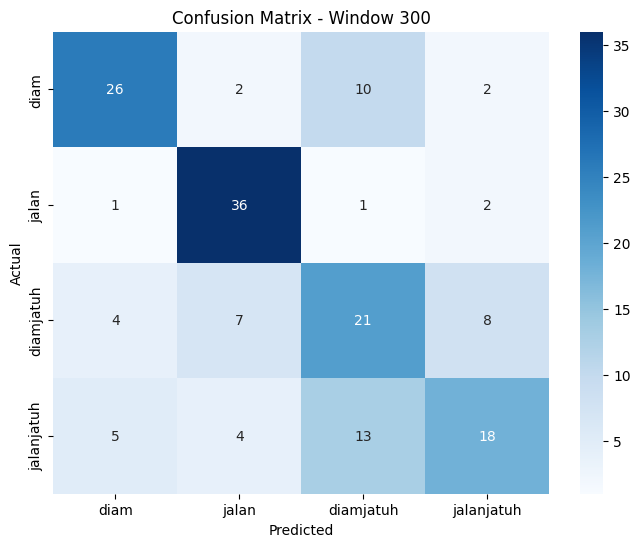

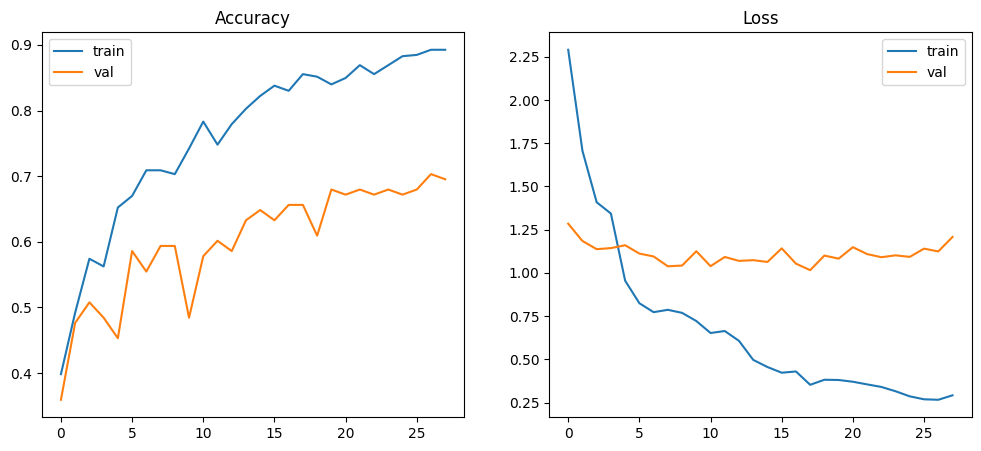

In [ ]:
# CNN 1D TRAINING - DATASET WINDOW 300


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# LOAD DATASET

path = "/content/drive/My Drive/Colab Notebooks/datasetready_300/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")
y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# MODEL CNN 1D

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(300,6)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

# COMPILE

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# CALLBACKS

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_window300.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# TRAINING

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,
    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

# EVALUASI

loss, acc = model.evaluate(X_test, y_test)

print("\n=================================")
print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))
print("=================================")

# PREDIKSI

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# CLASSIFICATION REPORT

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=kelas))

# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix - Window 300")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# GRAFIK TRAINING

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING FINAL - WINDOW 400

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# KONFIGURASI

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"

save_path = "/content/drive/My Drive/Colab Notebooks/datasetready_400/"
os.makedirs(save_path, exist_ok=True)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 400
stride = 400      # tanpa overlap


# LIST DATA


X = []
y = []

# WINDOWING


for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df.values   # 6 kolom sensor

    total_window = 0

    for i in range(0, len(data) - window + 1, stride):

        segmen = data[i:i+window]

        X.append(segmen)
        y.append(label)

        total_window += 1

    print("Jumlah Window:", total_window)


# NUMPY ARRAY


X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("\n================================")
print("Shape X :", X.shape)
print("Shape y :", y.shape)
print("================================")


# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# STANDARDIZATION

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(-1, fitur)
X_test_2d  = X_test.reshape(-1, fitur)

# fit hanya train
scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d)
X_test_scaled  = scaler.transform(X_test_2d)

# balik shape
X_train = X_train_scaled.reshape(
    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(
    X_test.shape[0],
    timestep,
    fitur
)


# SAVE DATASET

np.save(save_path + "X_train.npy", X_train)
np.save(save_path + "X_test.npy", X_test)
np.save(save_path + "y_train.npy", y_train)
np.save(save_path + "y_test.npy", y_test)

print("Dataset Window 400 Siap CNN")
print("Saved to:", save_path)

Processing: diam
Jumlah Window: 150
Processing: jalan
Jumlah Window: 150
Processing: diamjatuh
Jumlah Window: 150
Processing: jalanjatuh
Jumlah Window: 150

Shape X : (600, 400, 6)
Shape y : (600,)
Train : (480, 400, 6)
Test  : (120, 400, 6)

Dataset Window 400 Siap CNN
Saved to: /content/drive/My Drive/Colab Notebooks/datasetready_400/


Train : (480, 400, 6)
Test  : (120, 400, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 396, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 396, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 198, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 196, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 196, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 96, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 96, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6144)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       786,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 827,876 (3.16 MB)

...


Epoch 17: finished saving model to best_model_window400.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8698 - loss: 0.3405 - val_accuracy: 0.6354 - val_loss: 1.1119 - learning_rate: 5.0000e-04
Epoch 18/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8709 - loss: 0.3236
Epoch 18: val_accuracy did not improve from 0.63542
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8646 - loss: 0.3265 - val_accuracy: 0.6250 - val_loss: 1.0578 - learning_rate: 5.0000e-04
Epoch 19/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8737 - loss: 0.3363
Epoch 19: val_accuracy improved from 0.63542 to 0.65625, saving model to best_model_window400.h5



Epoch 19: finished saving model to best_model_window400.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8698 - loss: 0.3425 - val_accuracy: 0.6562 - val_loss: 1.0011 - learning_rate: 5.0000e-04
Epoch 20/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8629 - loss: 0.3131
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: val_accuracy did not improve from 0.65625
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8672 - loss: 0.3112 - val_accuracy: 0.6562 - val_loss: 1.0326 - learning_rate: 5.0000e-04
Epoch 21/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9017 - loss: 0.2534
Epoch 21: val_accuracy improved from 0.65625 to 0.67708, saving model to best_model_window400.h5



Epoch 21: finished saving model to best_model_window400.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8880 - loss: 0.2767 - val_accuracy: 0.6771 - val_loss: 1.0132 - learning_rate: 2.5000e-04
Epoch 22/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8568 - loss: 0.3064
Epoch 22: val_accuracy did not improve from 0.67708
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8698 - loss: 0.2991 - val_accuracy: 0.6771 - val_loss: 1.0284 - learning_rate: 2.5000e-04
Epoch 23/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8907 - loss: 0.2984
Epoch 23: val_accuracy improved from 0.67708 to 0.69792, saving model to best_model_window400.h5



Epoch 23: finished saving model to best_model_window400.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8906 - loss: 0.3219 - val_accuracy: 0.6979 - val_loss: 0.9962 - learning_rate: 2.5000e-04
Epoch 24/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8847 - loss: 0.3138
Epoch 24: val_accuracy did not improve from 0.69792
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9036 - loss: 0.2638 - val_accuracy: 0.6875 - val_loss: 1.0005 - learning_rate: 2.5000e-04
Epoch 25/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9522 - loss: 0.2016
Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 25: val_accuracy did not improve from 0.69792
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9297 - loss: 0.1975 - val_accuracy: 0.6771 - val_loss: 1.0339 - learning_rate: 2.5000e-04
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5750 - loss: 0.9926 

TEST ACCURACY : 57.5 %
TEST LOSS     : 0.9926
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 113m

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

Classification Report:

              precision    recall  f1-score   support

        diam       0.59      0.53      0.56        30
       jalan       0.79      0.73      0.76        30
   diamjatuh       0.38      0.60      0.47        30
  jalanjatuh       0.72      0.43      0.54        30

    accuracy                           0.57       120
   macro avg       0.62      0.57      0.58       120
weighted avg       0.62      0.57      0.58       120



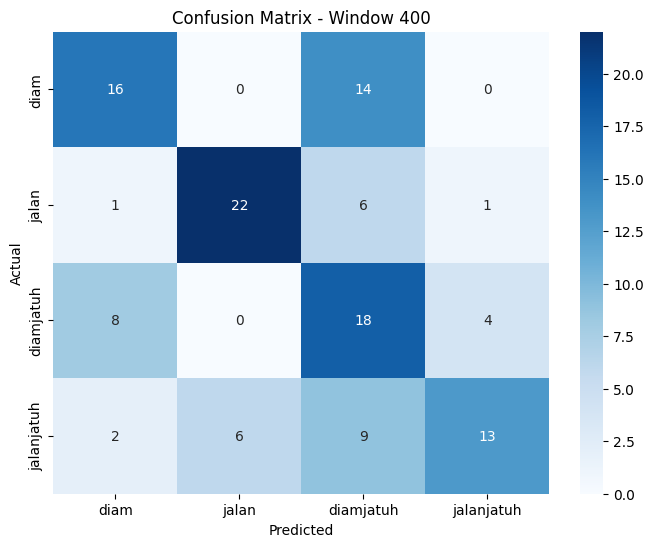

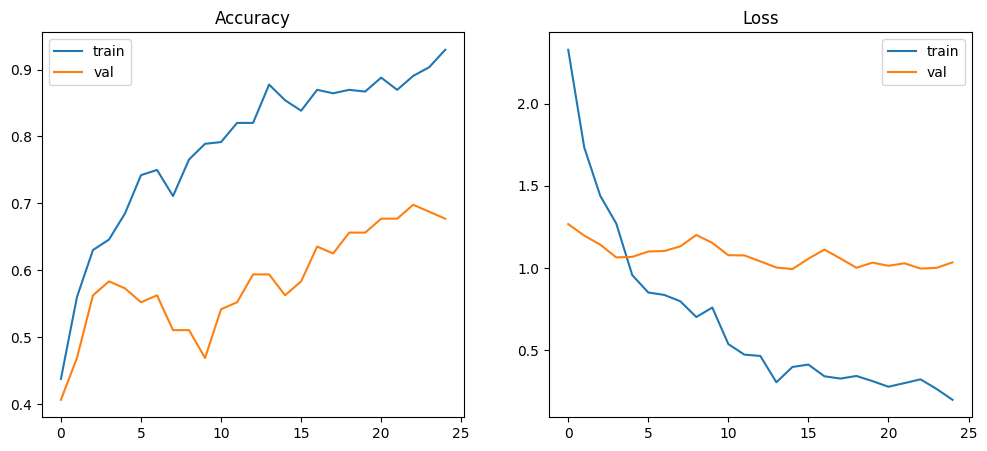

In [ ]:
# CNN 1D TRAINING - DATASET WINDOW 400

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# LOAD DATASET

path = "/content/drive/My Drive/Colab Notebooks/datasetready_400/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")
y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# MODEL CNN 1D

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(400,6)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

# COMPILE

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# CALLBACKS

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_window400.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# TRAINING

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,
    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

# EVALUASI

loss, acc = model.evaluate(X_test, y_test)

print("\n=================================")
print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))
print("=================================")

# PREDIKSI

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# CLASSIFICATION REPORT

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=kelas))

# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix - Window 400")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# GRAFIK TRAINING

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING FINAL - WINDOW 150

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# KONFIGURASI

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"

save_path = "/content/drive/My Drive/Colab Notebooks/datasetready_150/"
os.makedirs(save_path, exist_ok=True)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 150
stride = 150      # tanpa overlap

# LIST DATA

X = []
y = []

# WINDOWING

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df.values   # 6 kolom sensor

    total_window = 0

    for i in range(0, len(data) - window + 1, stride):

        segmen = data[i:i+window]

        X.append(segmen)
        y.append(label)

        total_window += 1

    print("Jumlah Window:", total_window)

# NUMPY ARRAY

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# STANDARDIZATION

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(-1, fitur)
X_test_2d  = X_test.reshape(-1, fitur)

# fit hanya train
scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d)
X_test_scaled  = scaler.transform(X_test_2d)

# balik shape
X_train = X_train_scaled.reshape(
    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(
    X_test.shape[0],
    timestep,
    fitur
)

# SAVE DATASET

np.save(save_path + "X_train.npy", X_train)
np.save(save_path + "X_test.npy", X_test)
np.save(save_path + "y_train.npy", y_train)
np.save(save_path + "y_test.npy", y_test)

print("\n")
print("Dataset Window 150 Siap CNN")
print("Saved to:", save_path)

Processing: diam
Jumlah Window: 400
Processing: jalan
Jumlah Window: 400
Processing: diamjatuh
Jumlah Window: 400
Processing: jalanjatuh
Jumlah Window: 400

Shape X : (1600, 150, 6)
Shape y : (1600,)
Train : (1280, 150, 6)
Test  : (320, 150, 6)

Dataset Window 150 Siap CNN
Saved to: /content/drive/My Drive/Colab Notebooks/datasetready_150/


Train : (1280, 150, 6)
Test  : (320, 150, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 146, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 146, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 73, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 71, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 71, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 35, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 33, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 33, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,588 (1.16 MB)

...


Epoch 9: finished saving model to best_model_window150.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7139 - loss: 0.6845 - val_accuracy: 0.6797 - val_loss: 0.7913 - learning_rate: 0.0010
Epoch 10/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7486 - loss: 0.6047
Epoch 10: val_accuracy did not improve from 0.67969
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7393 - loss: 0.6294 - val_accuracy: 0.6602 - val_loss: 0.7819 - learning_rate: 0.0010
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7310 - loss: 0.6432
Epoch 11: val_accuracy did not improve from 0.67969
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7227 - loss: 0.6534 - val_accuracy: 0.6328 - val_loss: 0.8342 - learning_rate: 0.0010
Epoch 12/100
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7442 - loss: 0.6098
Epoch 12: val_accuracy improved from 0.67969 to 0.68359, saving model to best_model_window150.h5



Epoch 12: finished saving model to best_model_window150.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7451 - loss: 0.6261 - val_accuracy: 0.6836 - val_loss: 0.7870 - learning_rate: 0.0010
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7542 - loss: 0.5794
Epoch 13: val_accuracy did not improve from 0.68359
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7451 - loss: 0.5909 - val_accuracy: 0.6758 - val_loss: 0.8668 - learning_rate: 0.0010
Epoch 14/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7859 - loss: 0.5240
Epoch 14: val_accuracy did not improve from 0.68359
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7705 - loss: 0.5638 - val_accuracy: 0.6680 - val_loss: 0.8293 - learning_rate: 0.0010
Epoch 15/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7834 - loss: 0.4948
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: val_accuracy did not improve from 0.68359
32/32 ━━━━━━━━━━━━━━━━━━━


Epoch 16: finished saving model to best_model_window150.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8066 - loss: 0.4802 - val_accuracy: 0.6953 - val_loss: 0.8096 - learning_rate: 5.0000e-04
Epoch 17/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8148 - loss: 0.4241
Epoch 17: val_accuracy improved from 0.69531 to 0.74609, saving model to best_model_window150.h5



Epoch 17: finished saving model to best_model_window150.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7910 - loss: 0.4639 - val_accuracy: 0.7461 - val_loss: 0.8366 - learning_rate: 5.0000e-04
Epoch 18/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7827 - loss: 0.5375
Epoch 18: val_accuracy did not improve from 0.74609
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7969 - loss: 0.4768 - val_accuracy: 0.7031 - val_loss: 0.8126 - learning_rate: 5.0000e-04
Epoch 19/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8433 - loss: 0.3977
Epoch 19: val_accuracy did not improve from 0.74609
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8379 - loss: 0.4006 - val_accuracy: 0.6914 - val_loss: 0.9131 - learning_rate: 5.0000e-04
Epoch 20/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8676 - loss: 0.3371
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: val_accuracy did not improve from 0.74609
32/32 ━━━━━━━

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  

Classification Report:

              precision    recall  f1-score   support

        diam       0.69      0.84      0.76        80
       jalan       0.78      0.80      0.79        80
   diamjatuh       0.56      0.53      0.54        80
  jalanjatuh       0.68      0.56      0.62        80

    accuracy                           0.68       320
   macro avg       0.68      0.68      0.68       320
weighted avg       0.68      0.68      0.68       320



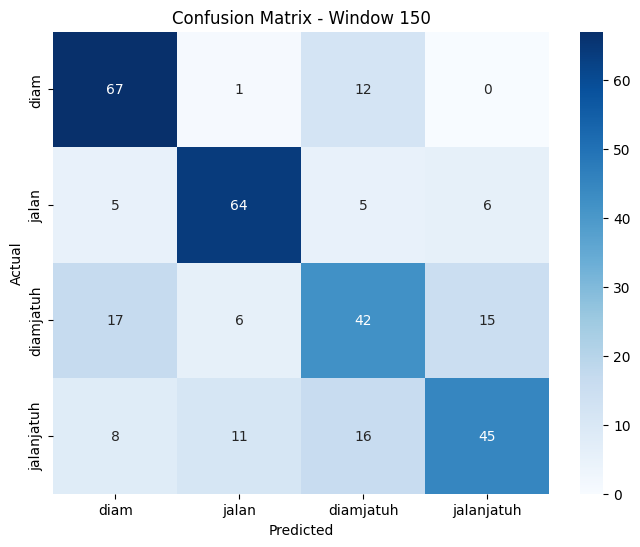

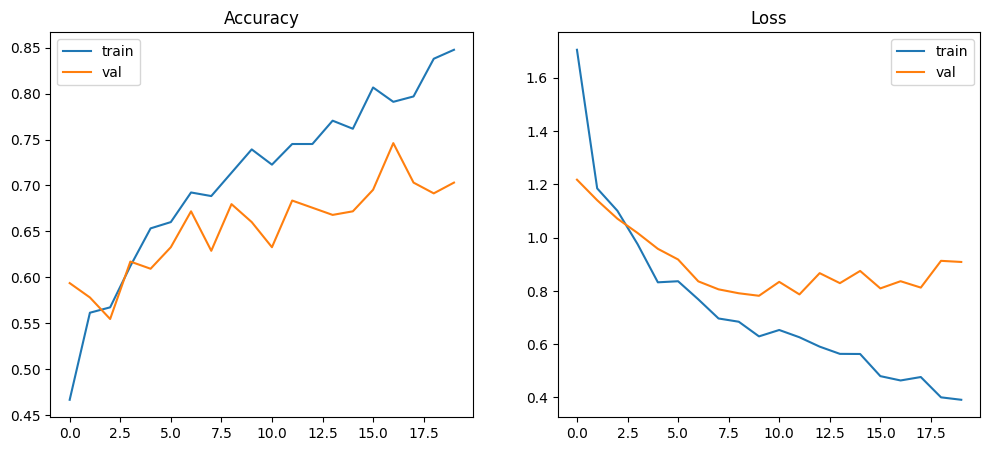

In [ ]:
# CNN 1D TRAINING - DATASET WINDOW 150

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# LOAD DATASET

path = "/content/drive/My Drive/Colab Notebooks/datasetready_150/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")
y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# MODEL CNN 1D

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(150,6)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

# COMPILE

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# CALLBACKS

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_window150.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# TRAINING

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,
    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

# EVALUASI

loss, acc = model.evaluate(X_test, y_test)

print("\n")
print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

# PREDIKSI

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# CLASSIFICATION REPORT

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=kelas))

# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix - Window 150")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# GRAFIK TRAINING

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING FINAL - WINDOW 250

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# KONFIGURASI

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"

save_path = "/content/drive/My Drive/Colab Notebooks/datasetready_250/"
os.makedirs(save_path, exist_ok=True)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 250
stride = 250      # tanpa overlap

# LIST DATA

X = []
y = []

# WINDOWING

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df.values   # 6 kolom sensor

    total_window = 0

    for i in range(0, len(data) - window + 1, stride):

        segmen = data[i:i+window]

        X.append(segmen)
        y.append(label)

        total_window += 1

    print("Jumlah Window:", total_window)

# NUMPY ARRAY

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("\n")
print("Shape X :", X.shape)
print("Shape y :", y.shape)

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# STANDARDIZATION

scaler = StandardScaler()

n_train, timestep, fitur = X_train.shape

X_train_2d = X_train.reshape(-1, fitur)
X_test_2d  = X_test.reshape(-1, fitur)

# fit hanya train
scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d)
X_test_scaled  = scaler.transform(X_test_2d)

# balik shape
X_train = X_train_scaled.reshape(
    X_train.shape[0],
    timestep,
    fitur
)

X_test = X_test_scaled.reshape(
    X_test.shape[0],
    timestep,
    fitur
)

# SAVE DATASET

np.save(save_path + "X_train.npy", X_train)
np.save(save_path + "X_test.npy", X_test)
np.save(save_path + "y_train.npy", y_train)
np.save(save_path + "y_test.npy", y_test)

print("\n")
print("Dataset Window 250 Siap CNN")
print("Saved to:", save_path)

Processing: diam
Jumlah Window: 240
Processing: jalan
Jumlah Window: 240
Processing: diamjatuh
Jumlah Window: 240
Processing: jalanjatuh
Jumlah Window: 240

Shape X : (960, 250, 6)
Shape y : (960,)
Train : (768, 250, 6)
Test  : (192, 250, 6)

Dataset Window 250 Siap CNN
Saved to: /content/drive/My Drive/Colab Notebooks/datasetready_250/


Train : (768, 250, 6)
Test  : (192, 250, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 246, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 246, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 123, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 121, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 121, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 58, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 58, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 29, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3712)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       475,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 516,580 (1.97 MB)

...


Epoch 13: finished saving model to best_model_window250.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7590 - loss: 0.6068 - val_accuracy: 0.6429 - val_loss: 0.8045 - learning_rate: 0.0010
Epoch 14/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7263 - loss: 0.6290
Epoch 14: val_accuracy did not improve from 0.64286
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7524 - loss: 0.5896 - val_accuracy: 0.6364 - val_loss: 0.8793 - learning_rate: 0.0010
Epoch 15/100
18/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7612 - loss: 0.5855
Epoch 15: val_accuracy improved from 0.64286 to 0.66234, saving model to best_model_window250.h5



Epoch 15: finished saving model to best_model_window250.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7524 - loss: 0.5688 - val_accuracy: 0.6623 - val_loss: 0.9270 - learning_rate: 0.0010
Epoch 16/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7801 - loss: 0.5499
Epoch 16: val_accuracy did not improve from 0.66234
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7932 - loss: 0.5225 - val_accuracy: 0.6494 - val_loss: 0.8826 - learning_rate: 0.0010
Epoch 17/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8291 - loss: 0.4571
Epoch 17: val_accuracy did not improve from 0.66234
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8176 - loss: 0.4904 - val_accuracy: 0.6623 - val_loss: 0.8757 - learning_rate: 0.0010
Epoch 18/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8363 - loss: 0.3695
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 18: val_accuracy did not improve from 0.66234
20/20 ━━━━━━━━━━━━━━━━━━━


Epoch 21: finished saving model to best_model_window250.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8388 - loss: 0.3877 - val_accuracy: 0.6883 - val_loss: 0.8226 - learning_rate: 5.0000e-04
Epoch 22/100
18/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8294 - loss: 0.3753
Epoch 22: val_accuracy improved from 0.68831 to 0.69481, saving model to best_model_window250.h5



Epoch 22: finished saving model to best_model_window250.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8111 - loss: 0.4241 - val_accuracy: 0.6948 - val_loss: 0.8074 - learning_rate: 5.0000e-04
Epoch 23/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8803 - loss: 0.3229
Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: val_accuracy improved from 0.69481 to 0.70779, saving model to best_model_window250.h5



Epoch 23: finished saving model to best_model_window250.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8811 - loss: 0.3258 - val_accuracy: 0.7078 - val_loss: 0.8660 - learning_rate: 5.0000e-04
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6875 - loss: 0.8884 

TEST ACCURACY : 68.75 %
TEST LOSS     : 0.8884
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  

Classification Report:

              precision    recall  f1-score   support

        diam       0.67      0.88      0.76        48
       jalan       0.69      0.92      0.79        48
   diamjatuh       0.71      0.42      0.53        48
  jalanjatuh       0.70      0.54      0.61        48

    accuracy                           0.69       192
   macro avg       0.69      0.69      0.67       192
weighted avg       0.69      0.69      0.67       192



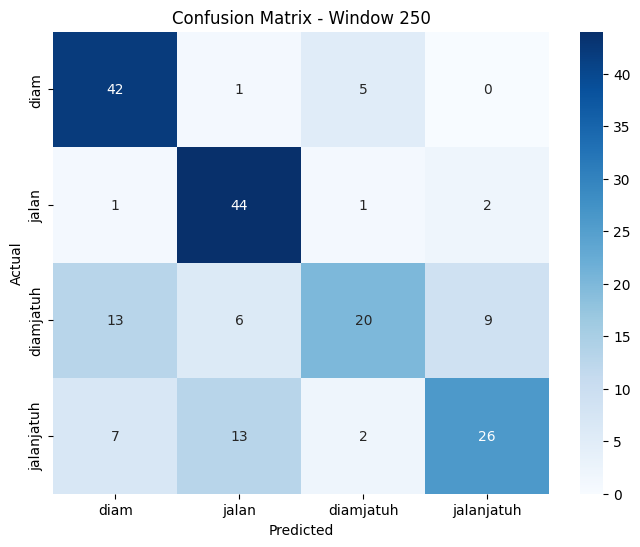

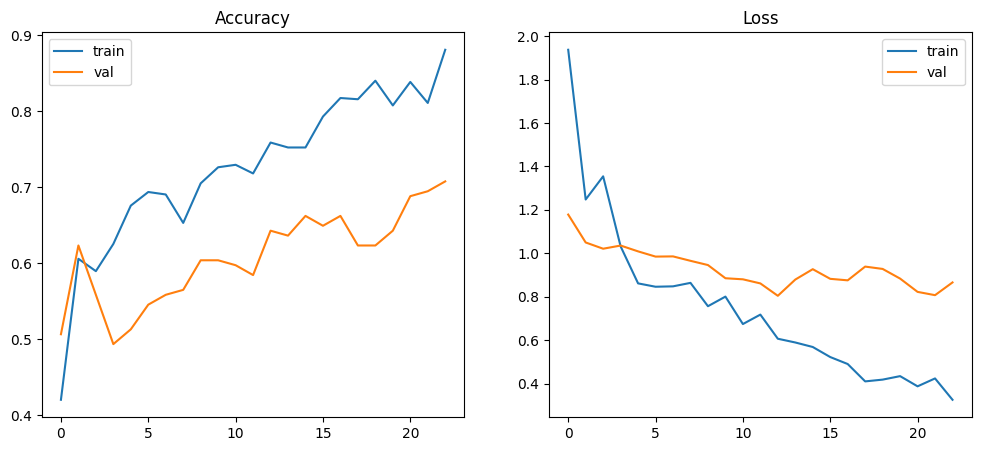

In [ ]:
# CNN 1D TRAINING - DATASET WINDOW 250

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# LOAD DATASET

path = "/content/drive/My Drive/Colab Notebooks/datasetready_250/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")
y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# MODEL CNN 1D

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(250,6)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

# COMPILE

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# CALLBACKS

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_window250.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# TRAINING

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,
    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

# EVALUASI

loss, acc = model.evaluate(X_test, y_test)

print("\n=================================")
print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))
print("=================================")

# PREDIKSI

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# CLASSIFICATION REPORT

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=kelas))

# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix - Window 250")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# GRAFIK TRAINING

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING FINAL - WINDOW 200 OVERLAP 50%

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"
save_path = "/content/drive/My Drive/Colab Notebooks/datasetready_200_overlap/"
os.makedirs(save_path, exist_ok=True)

kelas_files = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

window = 200
stride = 100     # overlap 50%

X=[]
y=[]

for nama_kelas,label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"
    df = pd.read_csv(file)

    data = df.values

    total = 0

    for i in range(0, len(data)-window+1, stride):

        segmen = data[i:i+window]

        X.append(segmen)
        y.append(label)

        total += 1

    print("Jumlah Window:", total)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# normalisasi
scaler = StandardScaler()

n,t,f = X_train.shape

X_train2 = X_train.reshape(-1,f)
X_test2  = X_test.reshape(-1,f)

scaler.fit(X_train2)

X_train = scaler.transform(X_train2).reshape(n,t,f)
X_test  = scaler.transform(X_test2).reshape(X_test.shape[0],t,f)

# save
np.save(save_path+"X_train.npy",X_train)
np.save(save_path+"X_test.npy",X_test)
np.save(save_path+"y_train.npy",y_train)
np.save(save_path+"y_test.npy",y_test)

print("Dataset overlap siap.")

Processing: diam
Jumlah Window: 599
Processing: jalan
Jumlah Window: 599
Processing: diamjatuh
Jumlah Window: 599
Processing: jalanjatuh
Jumlah Window: 599
Shape X: (2396, 200, 6)
Shape y: (2396,)
Dataset overlap siap.


Train : (1916, 200, 6)
Test  : (480, 200, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 196, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 196, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 96, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,276 (1.60 MB)

...


Epoch 11: finished saving model to best_model_window200_overlap.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7533 - loss: 0.5816 - val_accuracy: 0.7500 - val_loss: 0.6369 - learning_rate: 0.0010
Epoch 12/100
46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7728 - loss: 0.5333
Epoch 12: val_accuracy did not improve from 0.75000
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7617 - loss: 0.5722 - val_accuracy: 0.6979 - val_loss: 0.6869 - learning_rate: 0.0010
Epoch 13/100
46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7526 - loss: 0.5550
Epoch 13: val_accuracy did not improve from 0.75000
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7415 - loss: 0.5763 - val_accuracy: 0.6875 - val_loss: 0.6866 - learning_rate: 0.0010
Epoch 14/100
46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7784 - loss: 0.5264
Epoch 14: val_accuracy did not improve from 0.75000
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7774 - loss: 0.5137 - val_accuracy: 0.742


Epoch 20: finished saving model to best_model_window200_overlap.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8264 - loss: 0.3968 - val_accuracy: 0.7578 - val_loss: 0.5805 - learning_rate: 5.0000e-04
Epoch 21/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8585 - loss: 0.3303
Epoch 21: val_accuracy improved from 0.75781 to 0.76823, saving model to best_model_window200_overlap.h5



Epoch 21: finished saving model to best_model_window200_overlap.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8518 - loss: 0.3367 - val_accuracy: 0.7682 - val_loss: 0.5916 - learning_rate: 5.0000e-04
Epoch 22/100
46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8518 - loss: 0.3455
Epoch 22: val_accuracy did not improve from 0.76823
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8499 - loss: 0.3466 - val_accuracy: 0.7526 - val_loss: 0.6170 - learning_rate: 5.0000e-04
Epoch 23/100
46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8616 - loss: 0.3164
Epoch 23: val_accuracy did not improve from 0.76823
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8551 - loss: 0.3223 - val_accuracy: 0.7344 - val_loss: 0.6162 - learning_rate: 5.0000e-04
Epoch 24/100
46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8729 - loss: 0.3025
Epoch 24: val_accuracy did not improve from 0.76823
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8819 - loss: 0.2900 - val_acc


Epoch 26: finished saving model to best_model_window200_overlap.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8864 - loss: 0.2570 - val_accuracy: 0.7786 - val_loss: 0.5807 - learning_rate: 2.5000e-04
Epoch 27/100
46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8997 - loss: 0.2511
Epoch 27: val_accuracy did not improve from 0.77865
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8910 - loss: 0.2528 - val_accuracy: 0.7760 - val_loss: 0.6048 - learning_rate: 2.5000e-04
Epoch 28/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8914 - loss: 0.2512
Epoch 28: val_accuracy did not improve from 0.77865
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8969 - loss: 0.2447 - val_accuracy: 0.7786 - val_loss: 0.6165 - learning_rate: 2.5000e-04
Epoch 29/100
46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9020 - loss: 0.2367
Epoch 29: val_accuracy improved from 0.77865 to 0.78646, saving model to best_model_window200_overlap.h5



Epoch 29: finished saving model to best_model_window200_overlap.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8995 - loss: 0.2483 - val_accuracy: 0.7865 - val_loss: 0.6050 - learning_rate: 2.5000e-04
Epoch 30/100
46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8901 - loss: 0.2571
Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 30: val_accuracy did not improve from 0.78646
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8962 - loss: 0.2397 - val_accuracy: 0.7839 - val_loss: 0.5842 - learning_rate: 2.5000e-04
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7688 - loss: 0.6062

TEST ACCURACY : 76.88 %
TEST LOSS     : 0.6062
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Classification Report:

              precision    recall  f1-score   support

        diam       0.79      0.82      0.80       120
       jalan       0.89      0.88      0.88       120
   diamjatuh       0.64      0.69      0.66       120
  jalanjatuh       0.77  

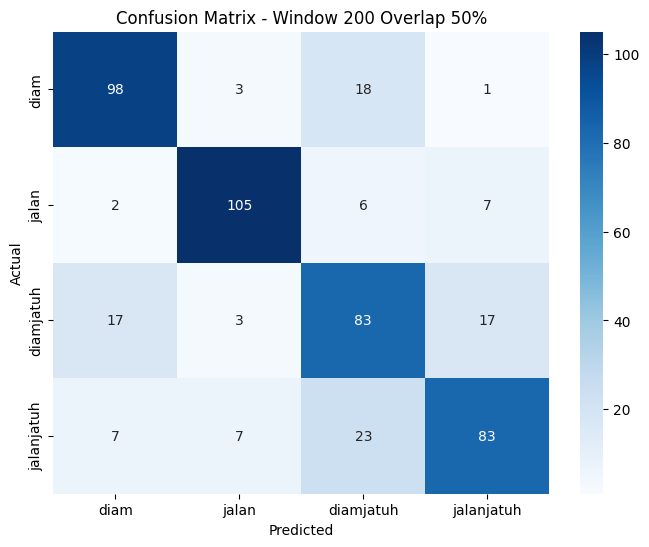

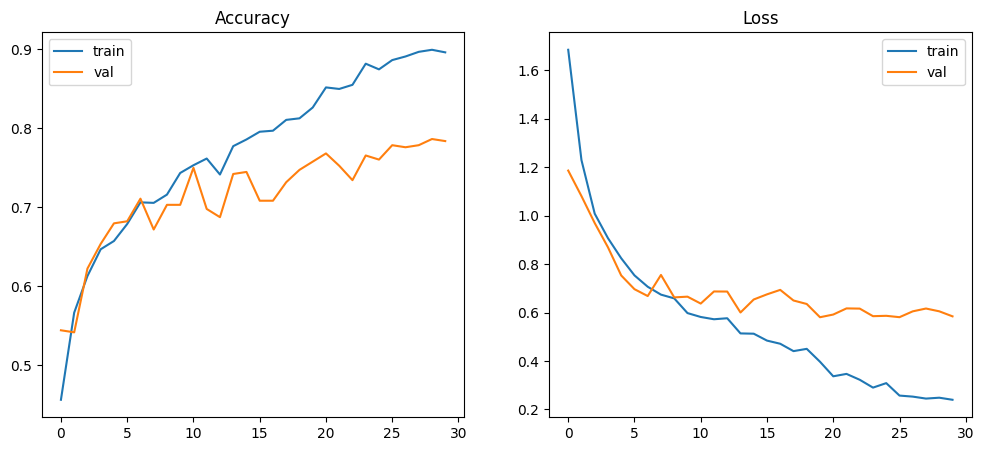

In [ ]:
# CNN 1D TRAINING - WINDOW 200 OVERLAP 50%
# Dataset: datasetready_200_overlap

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# LOAD DATASET

path = "/content/drive/My Drive/Colab Notebooks/datasetready_200_overlap/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")
y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# MODEL CNN 1D

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(200,6)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

# COMPILE

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# CALLBACKS

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_window200_overlap.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# TRAINING

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,
    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

# EVALUASI

loss, acc = model.evaluate(X_test, y_test)

print("\n")
print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

# PREDIKSI

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# CLASSIFICATION REPORT

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=kelas))

# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix - Window 200 Overlap 50%")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# GRAFIK TRAINING

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING FINAL - WINDOW 300 OVERLAP 50%

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"
save_path = "/content/drive/My Drive/Colab Notebooks/datasetready_300_overlap50%/"
os.makedirs(save_path, exist_ok=True)

kelas_files = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

window = 300
stride = 150     # overlap 50%

X=[]
y=[]

for nama_kelas,label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"
    df = pd.read_csv(file)

    data = df.values

    total = 0

    for i in range(0, len(data)-window+1, stride):

        segmen = data[i:i+window]

        X.append(segmen)
        y.append(label)

        total += 1

    print("Jumlah Window:", total)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# normalisasi
scaler = StandardScaler()

n,t,f = X_train.shape

X_train2 = X_train.reshape(-1,f)
X_test2  = X_test.reshape(-1,f)

scaler.fit(X_train2)

X_train = scaler.transform(X_train2).reshape(n,t,f)
X_test  = scaler.transform(X_test2).reshape(X_test.shape[0],t,f)

# save
np.save(save_path+"X_train.npy",X_train)
np.save(save_path+"X_test.npy",X_test)
np.save(save_path+"y_train.npy",y_train)
np.save(save_path+"y_test.npy",y_test)

print("Dataset overlap siap.")

Processing: diam
Jumlah Window: 399
Processing: jalan
Jumlah Window: 399
Processing: diamjatuh
Jumlah Window: 399
Processing: jalanjatuh
Jumlah Window: 399
Shape X: (1596, 300, 6)
Shape y: (1596,)
Dataset overlap siap.


Train : (1276, 300, 6)
Test  : (320, 300, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_21 (Conv1D)              │ (None, 296, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 296, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_21 (MaxPooling1D) │ (None, 148, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 146, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 146, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_22 (MaxPooling1D) │ (None, 73, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 71, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 71, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 35, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       573,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 614,884 (2.35 MB)

...


Epoch 11: finished saving model to best_model_window200_overlap.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7520 - loss: 0.5648 - val_accuracy: 0.7109 - val_loss: 0.8022 - learning_rate: 0.0010
Epoch 12/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7622 - loss: 0.5554
Epoch 12: val_accuracy did not improve from 0.71094
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7735 - loss: 0.5448 - val_accuracy: 0.7070 - val_loss: 0.7773 - learning_rate: 0.0010
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7644 - loss: 0.5501
Epoch 13: val_accuracy improved from 0.71094 to 0.73047, saving model to best_model_window200_overlap.h5



Epoch 13: finished saving model to best_model_window200_overlap.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7676 - loss: 0.5495 - val_accuracy: 0.7305 - val_loss: 0.8687 - learning_rate: 0.0010
Epoch 14/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7798 - loss: 0.4826
Epoch 14: val_accuracy did not improve from 0.73047
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7863 - loss: 0.4888 - val_accuracy: 0.7305 - val_loss: 0.7697 - learning_rate: 0.0010
Epoch 15/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7794 - loss: 0.5121
Epoch 15: val_accuracy did not improve from 0.73047
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8098 - loss: 0.4744 - val_accuracy: 0.7266 - val_loss: 0.7452 - learning_rate: 0.0010
Epoch 16/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7957 - loss: 0.5018
Epoch 16: val_accuracy did not improve from 0.73047
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7902 - loss: 0.4779 - val_accuracy: 0.722


Epoch 18: finished saving model to best_model_window200_overlap.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7873 - loss: 0.4882 - val_accuracy: 0.7383 - val_loss: 0.8566 - learning_rate: 0.0010
Epoch 19/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8126 - loss: 0.4820
Epoch 19: val_accuracy did not improve from 0.73828
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8118 - loss: 0.4557 - val_accuracy: 0.7031 - val_loss: 0.8467 - learning_rate: 0.0010
Epoch 20/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8249 - loss: 0.4362
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: val_accuracy did not improve from 0.73828
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8167 - loss: 0.4450 - val_accuracy: 0.7344 - val_loss: 0.7712 - learning_rate: 0.0010
Epoch 21/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8306 - loss: 0.3978
Epoch 21: val_accuracy did not improve from 0.73828
32/32 ━━━━━━━━━━━


Epoch 23: finished saving model to best_model_window200_overlap.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8814 - loss: 0.3226 - val_accuracy: 0.7617 - val_loss: 0.8303 - learning_rate: 5.0000e-04
Epoch 24/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8828 - loss: 0.2706
Epoch 24: val_accuracy did not improve from 0.76172
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8882 - loss: 0.2737 - val_accuracy: 0.7578 - val_loss: 0.7722 - learning_rate: 5.0000e-04
Epoch 25/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8943 - loss: 0.2545
Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 25: val_accuracy improved from 0.76172 to 0.76953, saving model to best_model_window200_overlap.h5



Epoch 25: finished saving model to best_model_window200_overlap.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8804 - loss: 0.2916 - val_accuracy: 0.7695 - val_loss: 0.7727 - learning_rate: 5.0000e-04
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7219 - loss: 0.6848


TEST ACCURACY : 72.19 %
TEST LOSS     : 0.6848
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Classification Report:

              precision    recall  f1-score   support

        diam       0.88      0.65      0.75        80
       jalan       0.77      0.86      0.81        80
   diamjatuh       0.61      0.61      0.61        80
  jalanjatuh       0.67      0.76      0.71        80

    accuracy                           0.72       320
   macro avg       0.73      0.72      0.72       320
weighted avg       0.73      0.72      0.72       320



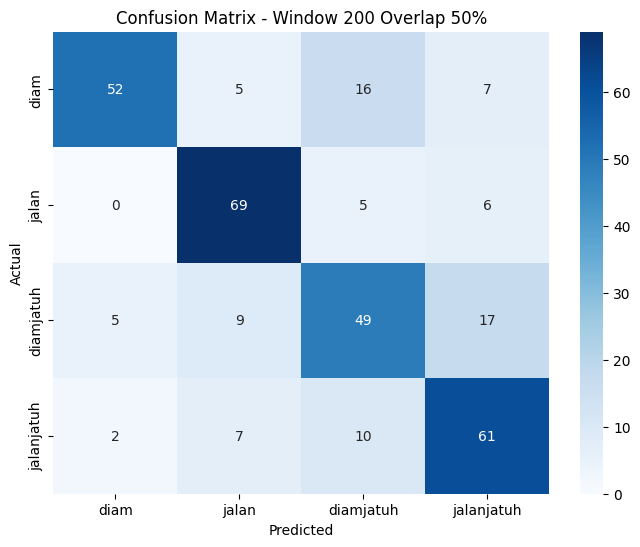

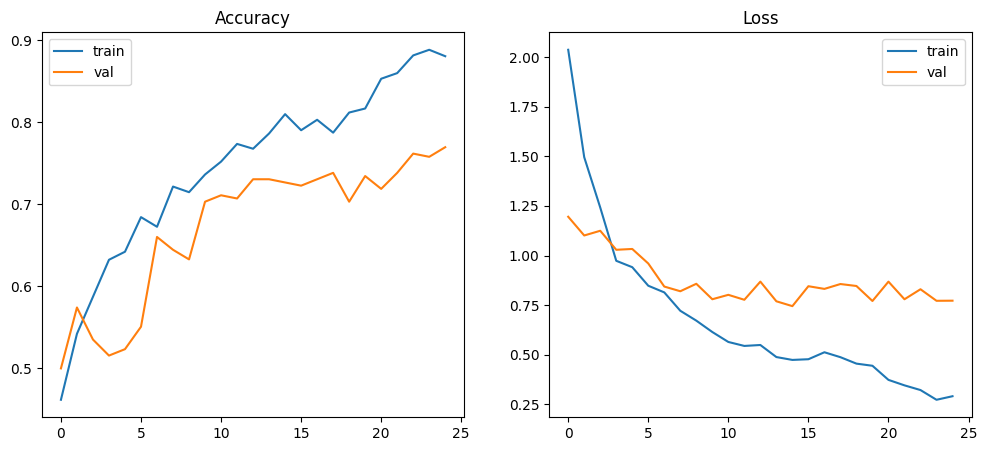

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# LOAD DATASET

path = "/content/drive/My Drive/Colab Notebooks/datasetready_300_overlap50%/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")
y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# MODEL CNN 1D

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(300,6) # Changed from (200,6) to (300,6)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

# COMPILE

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# CALLBACKS

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_window200_overlap.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# TRAINING

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,
    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

# EVALUASI

loss, acc = model.evaluate(X_test, y_test)

print("\n")
print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

# PREDIKSI

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# CLASSIFICATION REPORT

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=kelas))

# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix - Window 200 Overlap 50%")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# GRAFIK TRAINING

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING FINAL - WINDOW 200 OVERLAP 75%

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"
save_path = "/content/drive/My Drive/Colab Notebooks/datasetready_200_overlap75%/"
os.makedirs(save_path, exist_ok=True)

kelas_files = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

window = 200
stride = 150     # overlap 75%

X=[]
y=[]

for nama_kelas,label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"
    df = pd.read_csv(file)

    data = df.values

    total = 0

    for i in range(0, len(data)-window+1, stride):

        segmen = data[i:i+window]

        X.append(segmen)
        y.append(label)

        total += 1

    print("Jumlah Window:", total)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# normalisasi
scaler = StandardScaler()

n,t,f = X_train.shape

X_train2 = X_train.reshape(-1,f)
X_test2  = X_test.reshape(-1,f)

scaler.fit(X_train2)

X_train = scaler.transform(X_train2).reshape(n,t,f)
X_test  = scaler.transform(X_test2).reshape(X_test.shape[0],t,f)

# save
np.save(save_path+"X_train.npy",X_train)
np.save(save_path+"X_test.npy",X_test)
np.save(save_path+"y_train.npy",y_train)
np.save(save_path+"y_test.npy",y_test)

print("Dataset overlap siap.")

Processing: diam
Jumlah Window: 399
Processing: jalan
Jumlah Window: 399
Processing: diamjatuh
Jumlah Window: 399
Processing: jalanjatuh
Jumlah Window: 399
Shape X: (1596, 200, 6)
Shape y: (1596,)
Dataset overlap siap.


Train : (1276, 200, 6)
Test  : (320, 200, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_27 (Conv1D)              │ (None, 196, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 196, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_27 (MaxPooling1D) │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 96, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_28 (MaxPooling1D) │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_29 (MaxPooling1D) │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,276 (1.60 MB)

...


Epoch 12: finished saving model to best_model_window200_overlap.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7627 - loss: 0.5538 - val_accuracy: 0.6992 - val_loss: 0.7225 - learning_rate: 0.0010
Epoch 13/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7807 - loss: 0.5244
Epoch 13: val_accuracy improved from 0.69922 to 0.71484, saving model to best_model_window200_overlap.h5



Epoch 13: finished saving model to best_model_window200_overlap.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7775 - loss: 0.5507 - val_accuracy: 0.7148 - val_loss: 0.7043 - learning_rate: 0.0010
Epoch 14/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7768 - loss: 0.5223
Epoch 14: val_accuracy did not improve from 0.71484
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7784 - loss: 0.5329 - val_accuracy: 0.6992 - val_loss: 0.7899 - learning_rate: 0.0010
Epoch 15/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8170 - loss: 0.4810
Epoch 15: val_accuracy did not improve from 0.71484
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7892 - loss: 0.5182 - val_accuracy: 0.7148 - val_loss: 0.8370 - learning_rate: 0.0010
Epoch 16/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8119 - loss: 0.4519
Epoch 16: val_accuracy improved from 0.71484 to 0.74609, saving model to best_model_window200_overlap.h5



Epoch 16: finished saving model to best_model_window200_overlap.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7961 - loss: 0.4739 - val_accuracy: 0.7461 - val_loss: 0.7053 - learning_rate: 0.0010
Epoch 17/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8105 - loss: 0.4402
Epoch 17: val_accuracy did not improve from 0.74609
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7873 - loss: 0.4964 - val_accuracy: 0.7031 - val_loss: 0.7821 - learning_rate: 0.0010
Epoch 18/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8041 - loss: 0.4637
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 18: val_accuracy did not improve from 0.74609
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8059 - loss: 0.4809 - val_accuracy: 0.6953 - val_loss: 0.8537 - learning_rate: 0.0010
Epoch 19/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8461 - loss: 0.3925
Epoch 19: val_accuracy did not improve from 0.74609
32/32 ━━━━━━━━━━━


Epoch 21: finished saving model to best_model_window200_overlap.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8549 - loss: 0.3564 - val_accuracy: 0.7500 - val_loss: 0.7158 - learning_rate: 5.0000e-04
Epoch 22/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8993 - loss: 0.2766
Epoch 22: val_accuracy improved from 0.75000 to 0.76953, saving model to best_model_window200_overlap.h5



Epoch 22: finished saving model to best_model_window200_overlap.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8843 - loss: 0.3045 - val_accuracy: 0.7695 - val_loss: 0.7372 - learning_rate: 5.0000e-04
Epoch 23/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8775 - loss: 0.3195
Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: val_accuracy did not improve from 0.76953
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8706 - loss: 0.3413 - val_accuracy: 0.7500 - val_loss: 0.7462 - learning_rate: 5.0000e-04
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7281 - loss: 0.6671 


TEST ACCURACY : 72.81 %
TEST LOSS     : 0.6671
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Classification Report:

              precision    recall  f1-score   support

        diam       0.79      0.85      0.82        80
       jalan       0.81      0.85      0.83        80
   diamjatuh       0.61      0.57      0.59        80
  jalanjatuh       0.69

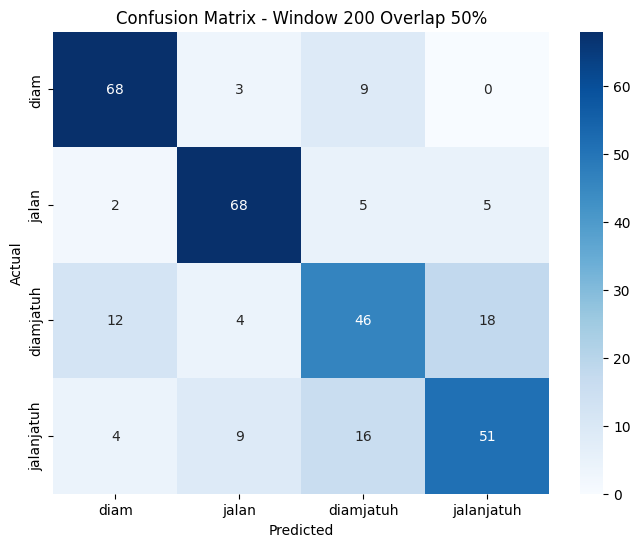

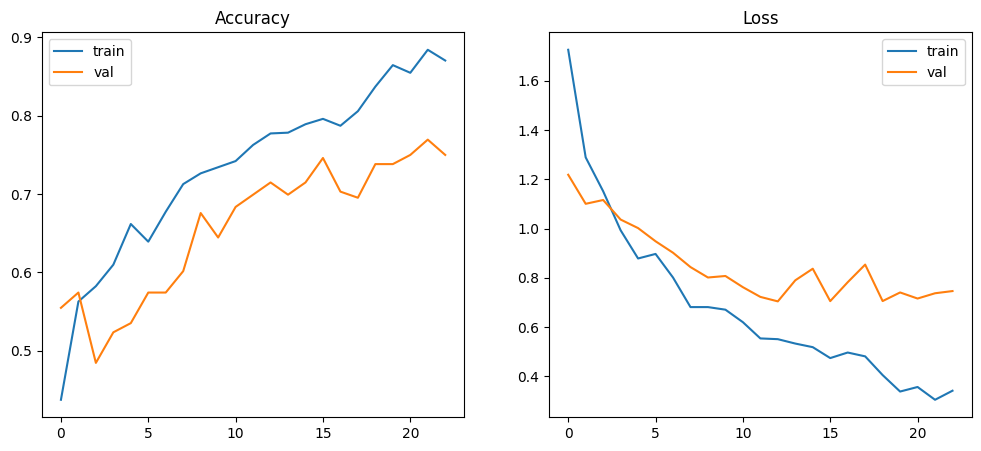

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# LOAD DATASET

path = "/content/drive/My Drive/Colab Notebooks/datasetready_200_overlap75%/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")
y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# MODEL CNN 1D

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(200,6) # Changed from (300,6) to (200,6) for window 200 dataset
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

# COMPILE

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# CALLBACKS

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_window200_overlap.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# TRAINING

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,
    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

# EVALUASI

loss, acc = model.evaluate(X_test, y_test)

print("\n")
print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

# PREDIKSI

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# CLASSIFICATION REPORT

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=kelas))

# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix - Window 200 Overlap 50%")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# GRAFIK TRAINING

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# PREPROCESSING FINAL - WINDOW 200 OVERLAP 25%

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"
save_path = "/content/drive/My Drive/Colab Notebooks/datasetready_200_overlap25%/"
os.makedirs(save_path, exist_ok=True)

kelas_files = {
    "diam":0,
    "jalan":1,
    "diamjatuh":2,
    "jalanjatuh":3
}

window = 200
stride = 50     # overlap 25%

X=[]
y=[]

for nama_kelas,label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"
    df = pd.read_csv(file)

    data = df.values

    total = 0

    for i in range(0, len(data)-window+1, stride):

        segmen = data[i:i+window]

        X.append(segmen)
        y.append(label)

        total += 1

    print("Jumlah Window:", total)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# normalisasi
scaler = StandardScaler()

n,t,f = X_train.shape

X_train2 = X_train.reshape(-1,f)
X_test2  = X_test.reshape(-1,f)

scaler.fit(X_train2)

X_train = scaler.transform(X_train2).reshape(n,t,f)
X_test  = scaler.transform(X_test2).reshape(X_test.shape[0],t,f)

# save
np.save(save_path+"X_train.npy",X_train)
np.save(save_path+"X_test.npy",X_test)
np.save(save_path+"y_train.npy",y_train)
np.save(save_path+"y_test.npy",y_test)

print("Dataset overlap siap.")

Processing: diam
Jumlah Window: 1197
Processing: jalan
Jumlah Window: 1197
Processing: diamjatuh
Jumlah Window: 1197
Processing: jalanjatuh
Jumlah Window: 1197
Shape X: (4788, 200, 6)
Shape y: (4788,)
Dataset overlap siap.


Train : (3830, 200, 6)
Test  : (958, 200, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_30 (Conv1D)              │ (None, 196, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 196, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_30 (MaxPooling1D) │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_31 (Conv1D)              │ (None, 96, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_31 (MaxPooling1D) │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_32 (Conv1D)              │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_32 (MaxPooling1D) │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,276 (1.60 MB)

...


Epoch 33: finished saving model to best_model_window200_overlap.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9164 - loss: 0.2034 - val_accuracy: 0.8368 - val_loss: 0.4999 - learning_rate: 5.0000e-04
Epoch 34/100
94/96 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9171 - loss: 0.1834
Epoch 34: val_accuracy improved from 0.83681 to 0.84073, saving model to best_model_window200_overlap.h5



Epoch 34: finished saving model to best_model_window200_overlap.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9262 - loss: 0.1734 - val_accuracy: 0.8407 - val_loss: 0.4934 - learning_rate: 5.0000e-04
Epoch 35/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9235 - loss: 0.1865
Epoch 35: val_accuracy improved from 0.84073 to 0.85248, saving model to best_model_window200_overlap.h5



Epoch 35: finished saving model to best_model_window200_overlap.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9259 - loss: 0.1845 - val_accuracy: 0.8525 - val_loss: 0.5082 - learning_rate: 5.0000e-04
Epoch 36/100
94/96 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9290 - loss: 0.1725
Epoch 36: val_accuracy did not improve from 0.85248
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9272 - loss: 0.1819 - val_accuracy: 0.8381 - val_loss: 0.4855 - learning_rate: 5.0000e-04
Epoch 37/100
94/96 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9372 - loss: 0.1477
Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 37: val_accuracy did not improve from 0.85248
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9298 - loss: 0.1629 - val_accuracy: 0.8499 - val_loss: 0.4665 - learning_rate: 5.0000e-04
Epoch 38/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9348 - loss: 0.1744
Epoch 38: val_accuracy did not improve from 0.85248
96/96


Epoch 39: finished saving model to best_model_window200_overlap.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9510 - loss: 0.1330 - val_accuracy: 0.8564 - val_loss: 0.4664 - learning_rate: 2.5000e-04
Epoch 40/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9508 - loss: 0.1162
Epoch 40: val_accuracy did not improve from 0.85640
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9439 - loss: 0.1303 - val_accuracy: 0.8551 - val_loss: 0.4800 - learning_rate: 2.5000e-04
Epoch 41/100
94/96 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9501 - loss: 0.1176
Epoch 41: val_accuracy did not improve from 0.85640
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9497 - loss: 0.1178 - val_accuracy: 0.8551 - val_loss: 0.5053 - learning_rate: 2.5000e-04
Epoch 42/100
94/96 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9563 - loss: 0.1099
Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 42: val_accuracy improved from 0.85640 to 0.86292, 


Epoch 42: finished saving model to best_model_window200_overlap.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9517 - loss: 0.1163 - val_accuracy: 0.8629 - val_loss: 0.4804 - learning_rate: 2.5000e-04
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8528 - loss: 0.3964


TEST ACCURACY : 85.28 %
TEST LOSS     : 0.3964
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Classification Report:

              precision    recall  f1-score   support

        diam       0.87      0.86      0.87       240
       jalan       0.91      0.90      0.91       239
   diamjatuh       0.74      0.80      0.77       240
  jalanjatuh       0.90      0.85      0.88       239

    accuracy                           0.85       958
   macro avg       0.86      0.85      0.85       958
weighted avg       0.86      0.85      0.85       958



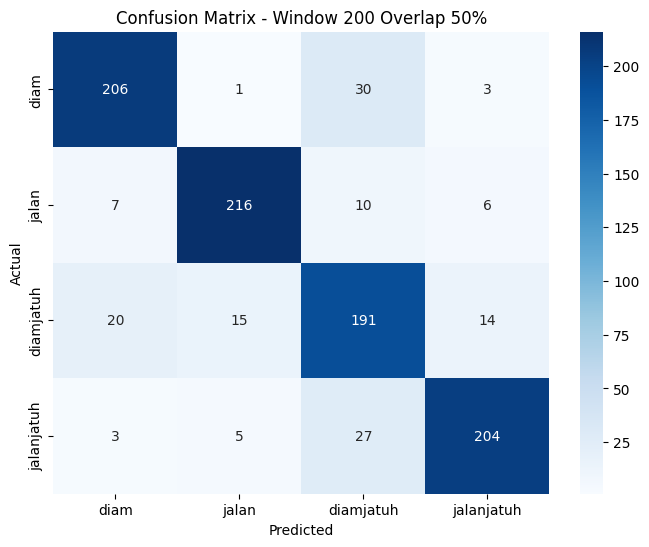

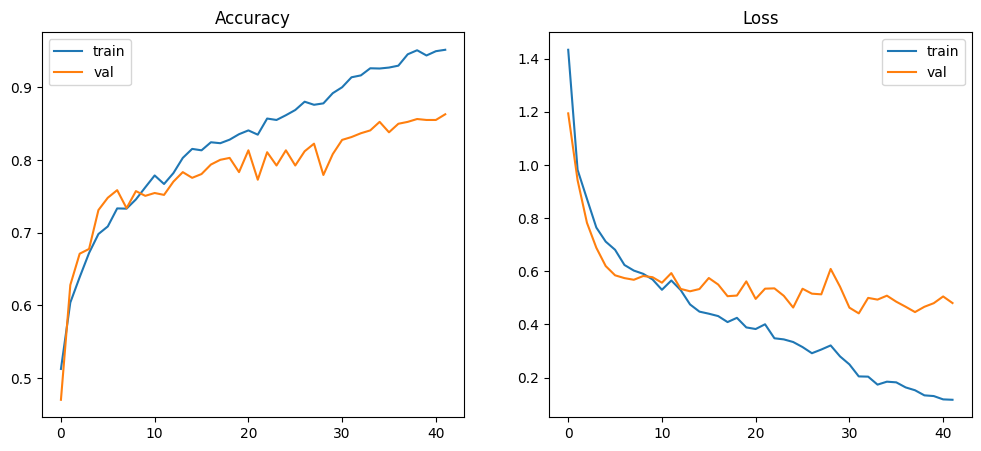

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# LOAD DATASET

path = "/content/drive/My Drive/Colab Notebooks/datasetready_200_overlap25%/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")
y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# MODEL CNN 1D

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(200,6) # Changed from (300,6) to (200,6) for window 200 dataset
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

# COMPILE

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# CALLBACKS

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_window200_overlap.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# TRAINING

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,
    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

# EVALUASI

loss, acc = model.evaluate(X_test, y_test)

print("\n")
print("TEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

# PREDIKSI

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# CLASSIFICATION REPORT

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=kelas))

# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix - Window 200 Overlap 50%")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# GRAFIK TRAINING

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# =========================================
# PREPROCESSING FINAL
# WINDOW 200 OVERLAP 25%
# =========================================

import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================================
# PATH
# =========================================

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"
save_path = "/content/drive/My Drive/Colab Notebooks/datasetready_200_overlap25/"

os.makedirs(save_path, exist_ok=True)

# =========================================
# LABEL KELAS
# =========================================

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

# =========================================
# WINDOWING
# =========================================

window = 200

# overlap 25%
# stride = 75% dari window
# 200 x 0.75 = 150

stride = 150

X = []
y = []

# =========================================
# LOOP DATASET
# =========================================

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df.values

    total = 0

    # windowing overlap
    for i in range(0, len(data) - window + 1, stride):

        segmen = data[i:i + window]

        X.append(segmen)
        y.append(label)

        total += 1

    print("Jumlah Window:", total)

# =========================================
# CONVERT NUMPY
# =========================================

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("\n================================")
print("Shape X :", X.shape)
print("Shape y :", y.shape)
print("================================")

# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

# =========================================
# NORMALISASI
# =========================================

scaler = StandardScaler()

n, t, f = X_train.shape

# reshape untuk scaler
X_train2 = X_train.reshape(-1, f)
X_test2  = X_test.reshape(-1, f)

# fit scaler hanya train
scaler.fit(X_train2)

# transform
X_train = scaler.transform(X_train2).reshape(n, t, f)

X_test = scaler.transform(X_test2).reshape(
    X_test.shape[0],
    t,
    f
)

# =========================================
# SAVE DATASET
# =========================================

np.save(save_path + "X_train.npy", X_train)
np.save(save_path + "X_test.npy", X_test)

np.save(save_path + "y_train.npy", y_train)
np.save(save_path + "y_test.npy", y_test)

print("\n================================")
print("Dataset Window 200 Overlap 25%")
print("Saved to:", save_path)
print("================================")

In [ ]:
#window 200 overlap 25%
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"
save_path = "/content/drive/My Drive/Colab Notebooks/datasetready_200_overlap25/"

os.makedirs(save_path, exist_ok=True)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 200

# overlap 25%
# stride = 75% dari window
# 200 x 0.75 = 150

stride = 150

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df.values

    total = 0

    for i in range(0, len(data) - window + 1, stride):

        segmen = data[i:i + window]

        X.append(segmen)
        y.append(label)

        total += 1

    print("Jumlah Window:", total)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("\nShape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n, t, f = X_train.shape

X_train2 = X_train.reshape(-1, f)
X_test2  = X_test.reshape(-1, f)

scaler.fit(X_train2)

X_train = scaler.transform(X_train2).reshape(n, t, f)

X_test = scaler.transform(X_test2).reshape(
    X_test.shape[0],
    t,
    f
)

np.save(save_path + "X_train.npy", X_train)
np.save(save_path + "X_test.npy", X_test)

np.save(save_path + "y_train.npy", y_train)
np.save(save_path + "y_test.npy", y_test)

print("\nDataset Window 200 Overlap 25%")
print("Saved to:", save_path)

Processing: diam
Jumlah Window: 399
Processing: jalan
Jumlah Window: 399
Processing: diamjatuh
Jumlah Window: 399
Processing: jalanjatuh
Jumlah Window: 399

Shape X : (1596, 200, 6)
Shape y : (1596,)
Train : (1276, 200, 6)
Test  : (320, 200, 6)

Dataset Window 200 Overlap 25%
Saved to: /content/drive/My Drive/Colab Notebooks/datasetready_200_overlap25/


Train : (1276, 200, 6)
Test  : (320, 200, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_33 (Conv1D)              │ (None, 196, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 196, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_33 (MaxPooling1D) │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 96, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_34 (MaxPooling1D) │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_35 (MaxPooling1D) │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,276 (1.60 MB)

...


Epoch 6: finished saving model to best_model_window200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6657 - loss: 0.7932 - val_accuracy: 0.6641 - val_loss: 0.8269 - learning_rate: 0.0010
Epoch 7/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7153 - loss: 0.6610
Epoch 7: val_accuracy did not improve from 0.66406
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6990 - loss: 0.6838 - val_accuracy: 0.6055 - val_loss: 0.8516 - learning_rate: 0.0010
Epoch 8/100
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7256 - loss: 0.6429
Epoch 8: val_accuracy did not improve from 0.66406
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7176 - loss: 0.6795 - val_accuracy: 0.6445 - val_loss: 0.8386 - learning_rate: 0.0010
Epoch 9/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7303 - loss: 0.7219
Epoch 9: val_accuracy improved from 0.66406 to 0.69531, saving model to best_model_window200_overlap25.h5



Epoch 9: finished saving model to best_model_window200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7275 - loss: 0.6862 - val_accuracy: 0.6953 - val_loss: 0.7679 - learning_rate: 0.0010
Epoch 10/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7257 - loss: 0.6679
Epoch 10: val_accuracy did not improve from 0.69531
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7196 - loss: 0.6599 - val_accuracy: 0.6875 - val_loss: 0.7671 - learning_rate: 0.0010
Epoch 11/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7594 - loss: 0.5384
Epoch 11: val_accuracy did not improve from 0.69531
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7676 - loss: 0.5310 - val_accuracy: 0.6836 - val_loss: 0.8115 - learning_rate: 0.0010
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7779 - loss: 0.4909
Epoch 12: val_accuracy improved from 0.69531 to 0.70703, saving model to best_model_window200_overlap25.h5



Epoch 12: finished saving model to best_model_window200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7735 - loss: 0.5227 - val_accuracy: 0.7070 - val_loss: 0.7448 - learning_rate: 0.0010
Epoch 13/100
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7874 - loss: 0.5226
Epoch 13: val_accuracy did not improve from 0.70703
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7735 - loss: 0.5425 - val_accuracy: 0.6836 - val_loss: 0.7585 - learning_rate: 0.0010
Epoch 14/100
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7385 - loss: 0.5817
Epoch 14: val_accuracy improved from 0.70703 to 0.72656, saving model to best_model_window200_overlap25.h5



Epoch 14: finished saving model to best_model_window200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7520 - loss: 0.5483 - val_accuracy: 0.7266 - val_loss: 0.7690 - learning_rate: 0.0010
Epoch 15/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8086 - loss: 0.4502
Epoch 15: val_accuracy did not improve from 0.72656
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7755 - loss: 0.5368 - val_accuracy: 0.6914 - val_loss: 0.7357 - learning_rate: 0.0010
Epoch 16/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7813 - loss: 0.5594
Epoch 16: val_accuracy improved from 0.72656 to 0.74609, saving model to best_model_window200_overlap25.h5



Epoch 16: finished saving model to best_model_window200_overlap25.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7706 - loss: 0.5521 - val_accuracy: 0.7461 - val_loss: 0.7402 - learning_rate: 0.0010
Epoch 17/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8085 - loss: 0.4367
Epoch 17: val_accuracy did not improve from 0.74609
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8127 - loss: 0.4670 - val_accuracy: 0.7344 - val_loss: 0.8499 - learning_rate: 0.0010
Epoch 18/100
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8200 - loss: 0.4301
Epoch 18: val_accuracy did not improve from 0.74609
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8216 - loss: 0.4290 - val_accuracy: 0.7266 - val_loss: 0.7519 - learning_rate: 0.0010
Epoch 19/100
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7961 - loss: 0.4405
Epoch 19: val_accuracy did not improve from 0.74609
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7892 - loss: 0.4554 - val_accuracy: 0.7

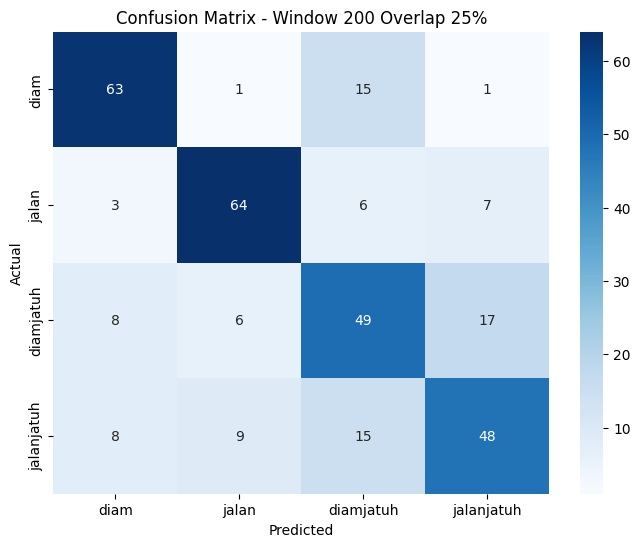

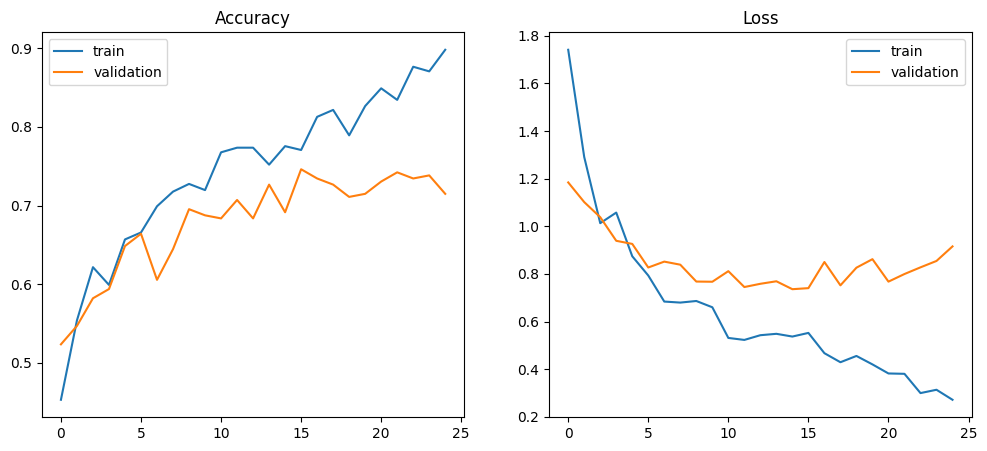

In [ ]:
#window 200 dengan overlap 25%
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

path = "/content/drive/My Drive/Colab Notebooks/datasetready_200_overlap25/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(200,6)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_window200_overlap25.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,
    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(X_test, y_test)

print("\nTEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix - Window 200 Overlap 25%")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='validation'
)

plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='validation'
)

plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
#window 200 dengan overlap 75%
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = "/content/drive/My Drive/Colab Notebooks/DATASET/datasetgabung/"
save_path = "/content/drive/My Drive/Colab Notebooks/datasetready_200_overlap75/"

os.makedirs(save_path, exist_ok=True)

kelas_files = {
    "diam": 0,
    "jalan": 1,
    "diamjatuh": 2,
    "jalanjatuh": 3
}

window = 200

# overlap 75%
# stride = 25% dari window
# 200 x 0.25 = 50

stride = 50

X = []
y = []

for nama_kelas, label in kelas_files.items():

    print("Processing:", nama_kelas)

    file = path + nama_kelas + ".csv"

    df = pd.read_csv(file)

    data = df.values

    total = 0

    for i in range(0, len(data) - window + 1, stride):

        segmen = data[i:i + window]

        X.append(segmen)
        y.append(label)

        total += 1

    print("Jumlah Window:", total)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("\nShape X :", X.shape)
print("Shape y :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

scaler = StandardScaler()

n, t, f = X_train.shape

X_train2 = X_train.reshape(-1, f)
X_test2  = X_test.reshape(-1, f)

scaler.fit(X_train2)

X_train = scaler.transform(X_train2).reshape(n, t, f)

X_test = scaler.transform(X_test2).reshape(
    X_test.shape[0],
    t,
    f
)

np.save(save_path + "X_train.npy", X_train)
np.save(save_path + "X_test.npy", X_test)

np.save(save_path + "y_train.npy", y_train)
np.save(save_path + "y_test.npy", y_test)

print("\nDataset Window 200 Overlap 75%")
print("Saved to:", save_path)

Processing: diam
Jumlah Window: 1197
Processing: jalan
Jumlah Window: 1197
Processing: diamjatuh
Jumlah Window: 1197
Processing: jalanjatuh
Jumlah Window: 1197

Shape X : (4788, 200, 6)
Shape y : (4788,)
Train : (3830, 200, 6)
Test  : (958, 200, 6)

Dataset Window 200 Overlap 75%
Saved to: /content/drive/My Drive/Colab Notebooks/datasetready_200_overlap75/


Train : (3830, 200, 6)
Test  : (958, 200, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_36 (Conv1D)              │ (None, 196, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 196, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_36 (MaxPooling1D) │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_37 (Conv1D)              │ (None, 96, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_37 (MaxPooling1D) │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_38 (Conv1D)              │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_38 (MaxPooling1D) │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,276 (1.60 MB)

...


Epoch 30: finished saving model to best_model_window200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9099 - loss: 0.2291 - val_accuracy: 0.8316 - val_loss: 0.4807 - learning_rate: 5.0000e-04
Epoch 31/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9138 - loss: 0.2089
Epoch 31: val_accuracy improved from 0.83159 to 0.83681, saving model to best_model_window200_overlap75.h5



Epoch 31: finished saving model to best_model_window200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9145 - loss: 0.2174 - val_accuracy: 0.8368 - val_loss: 0.4274 - learning_rate: 5.0000e-04
Epoch 32/100
94/96 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9203 - loss: 0.2101
Epoch 32: val_accuracy did not improve from 0.83681
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9279 - loss: 0.1952 - val_accuracy: 0.8225 - val_loss: 0.4748 - learning_rate: 5.0000e-04
Epoch 33/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9104 - loss: 0.2200
Epoch 33: val_accuracy did not improve from 0.83681
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9161 - loss: 0.2078 - val_accuracy: 0.8342 - val_loss: 0.4700 - learning_rate: 5.0000e-04
Epoch 34/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9318 - loss: 0.1799
Epoch 34: val_accuracy did not improve from 0.83681
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9243 - loss: 0.2029 - val_a


Epoch 37: finished saving model to best_model_window200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9334 - loss: 0.1673 - val_accuracy: 0.8512 - val_loss: 0.4277 - learning_rate: 2.5000e-04
Epoch 38/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9431 - loss: 0.1565
Epoch 38: val_accuracy improved from 0.85117 to 0.85640, saving model to best_model_window200_overlap75.h5



Epoch 38: finished saving model to best_model_window200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9429 - loss: 0.1499 - val_accuracy: 0.8564 - val_loss: 0.4261 - learning_rate: 2.5000e-04
Epoch 39/100
94/96 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9494 - loss: 0.1284
Epoch 39: val_accuracy did not improve from 0.85640
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9452 - loss: 0.1356 - val_accuracy: 0.8538 - val_loss: 0.4196 - learning_rate: 2.5000e-04
Epoch 40/100
94/96 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9552 - loss: 0.1146
Epoch 40: val_accuracy did not improve from 0.85640
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9553 - loss: 0.1177 - val_accuracy: 0.8486 - val_loss: 0.4319 - learning_rate: 2.5000e-04
Epoch 41/100
94/96 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9422 - loss: 0.1389
Epoch 41: val_accuracy did not improve from 0.85640
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9429 - loss: 0.1413 - val_a


Epoch 42: finished saving model to best_model_window200_overlap75.h5
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9478 - loss: 0.1290 - val_accuracy: 0.8642 - val_loss: 0.4352 - learning_rate: 2.5000e-04
Epoch 43/100
94/96 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9600 - loss: 0.1034
Epoch 43: val_accuracy did not improve from 0.86423
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9533 - loss: 0.1154 - val_accuracy: 0.8538 - val_loss: 0.4561 - learning_rate: 2.5000e-04
Epoch 44/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9552 - loss: 0.1124
Epoch 44: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 44: val_accuracy did not improve from 0.86423
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9475 - loss: 0.1277 - val_accuracy: 0.8446 - val_loss: 0.4716 - learning_rate: 2.5000e-04
Epoch 45/100
94/96 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9674 - loss: 0.1016
Epoch 45: val_accuracy did not improve from 0.86423
96/

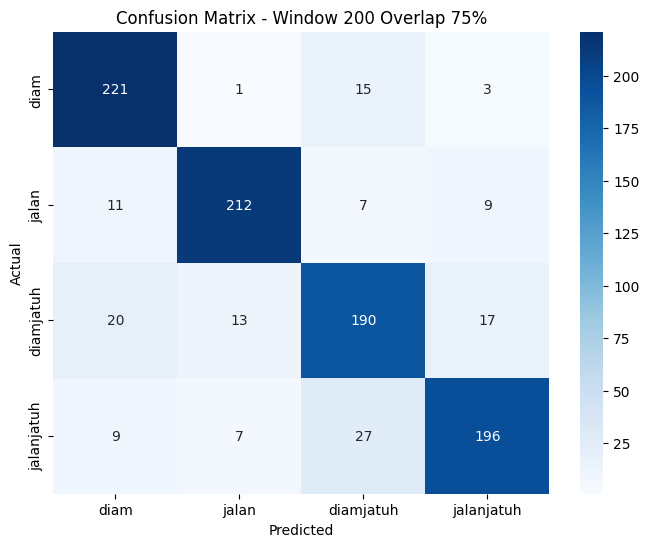

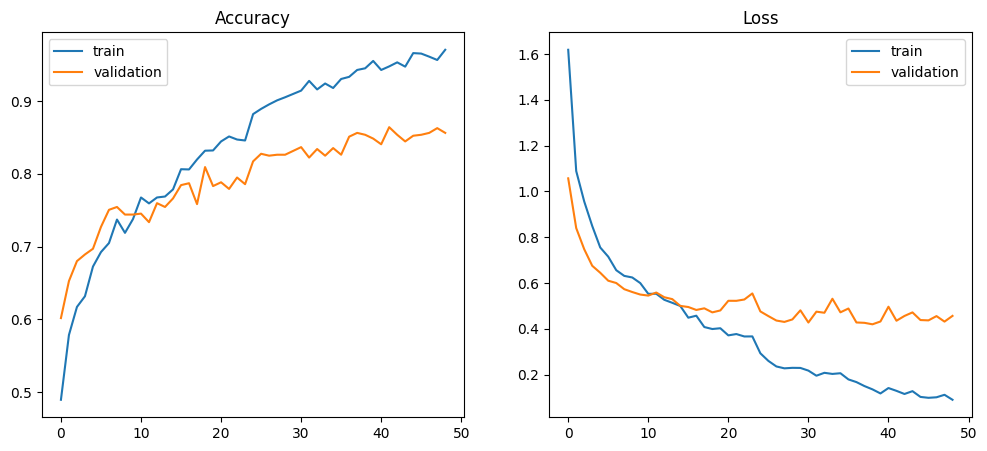

In [ ]:
#window 200 dengan overlap 75%
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

path = "/content/drive/My Drive/Colab Notebooks/datasetready_200_overlap75/"

X_train = np.load(path + "X_train.npy")
X_test  = np.load(path + "X_test.npy")

y_train = np.load(path + "y_train.npy")
y_test  = np.load(path + "y_test.npy")

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(200,6)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(
    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model_window200_overlap75.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,
    batch_size=32,

    callbacks=callbacks,

    verbose=1
)

loss, acc = model.evaluate(X_test, y_test)

print("\nTEST ACCURACY :", round(acc*100,2), "%")
print("TEST LOSS     :", round(loss,4))

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

kelas = [
    "diam",
    "jalan",
    "diamjatuh",
    "jalanjatuh"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=kelas
    )
)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=kelas,
    yticklabels=kelas
)

plt.title("Confusion Matrix - Window 200 Overlap 75%")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='validation'
)

plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='validation'
)

plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
model.save("/content/drive/My Drive/model_final_85_28.h5")

Shape X_train : (3830, 200, 6)
Shape y_train : (3830,)

KELAS : diam
Jumlah Window : 957
ax -> Dominant Freq = 0.195 Hz | Power = 0.78104


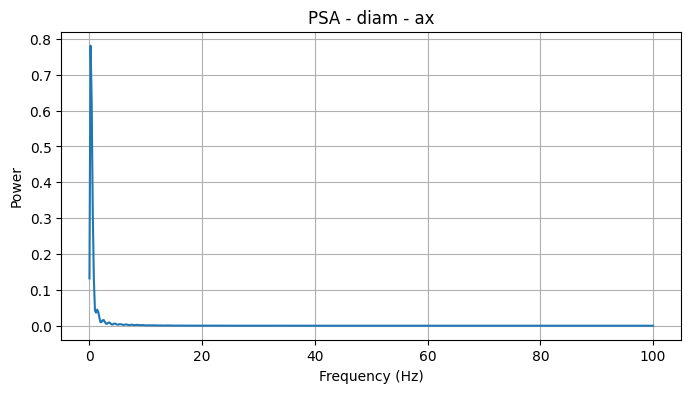

ay -> Dominant Freq = 0.195 Hz | Power = 0.80935


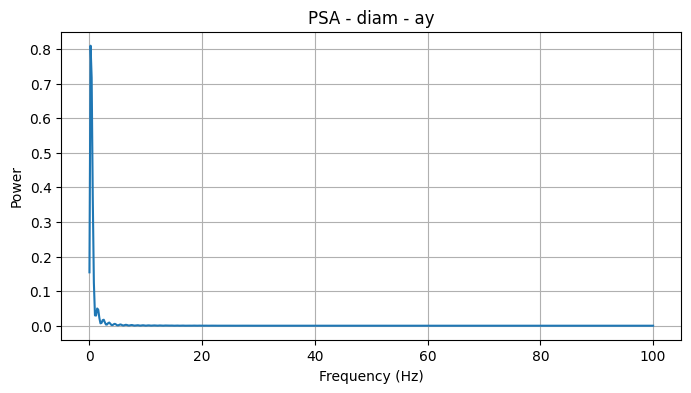

az -> Dominant Freq = 0.195 Hz | Power = 1.46518


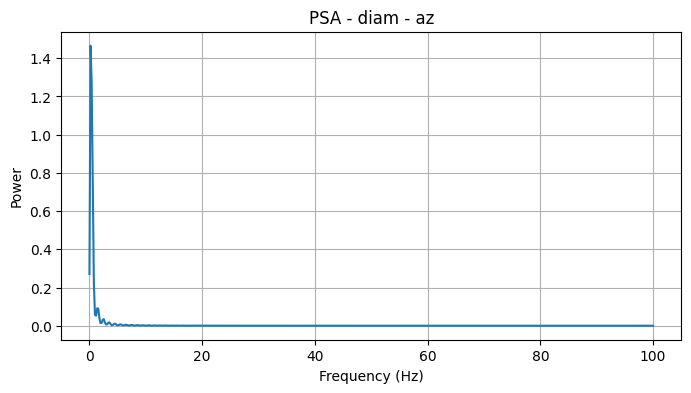

gx -> Dominant Freq = 0.391 Hz | Power = 0.16673


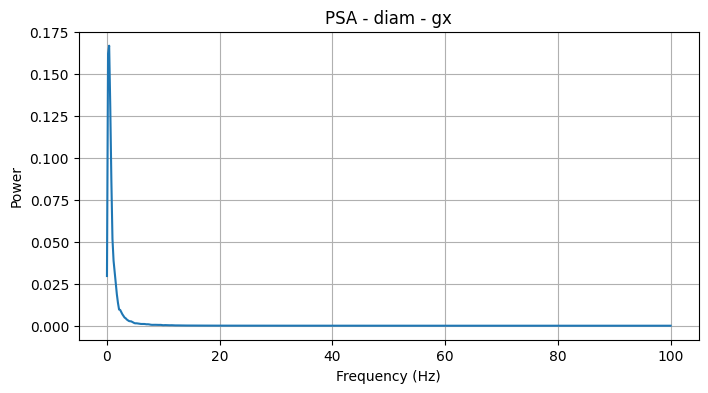

gy -> Dominant Freq = 0.391 Hz | Power = 0.09148


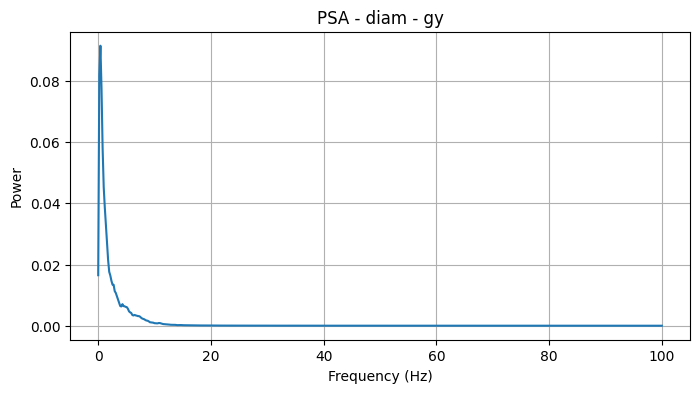

gz -> Dominant Freq = 0.391 Hz | Power = 0.06629


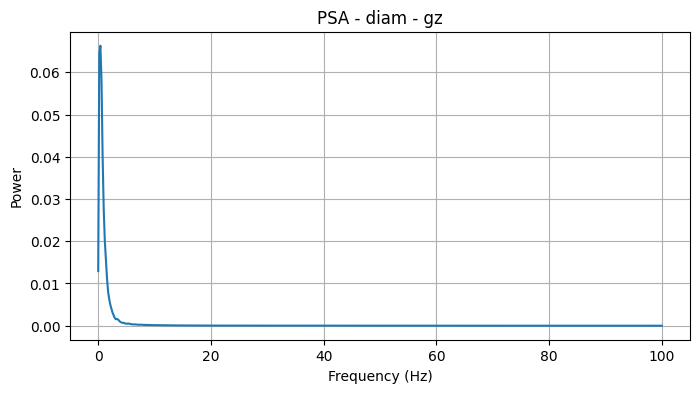


KELAS : jalan
Jumlah Window : 958
ax -> Dominant Freq = 0.195 Hz | Power = 0.15234


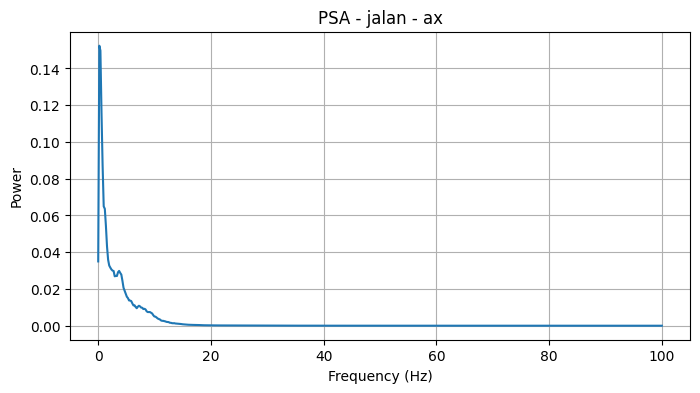

ay -> Dominant Freq = 0.195 Hz | Power = 0.3662


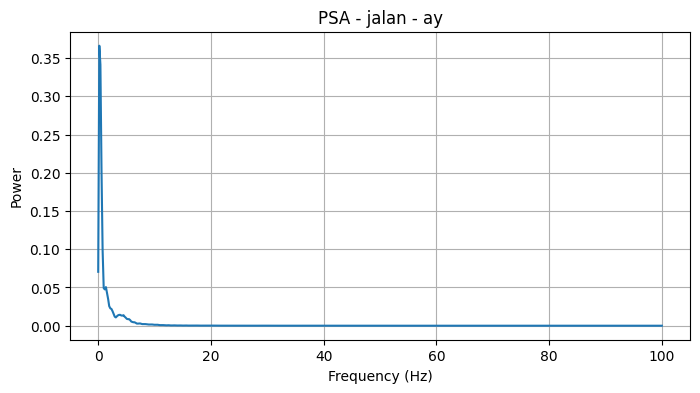

az -> Dominant Freq = 0.195 Hz | Power = 0.17703


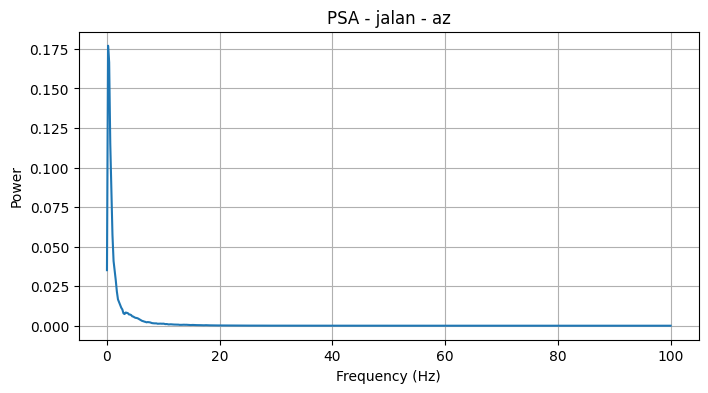

gx -> Dominant Freq = 0.391 Hz | Power = 0.78118


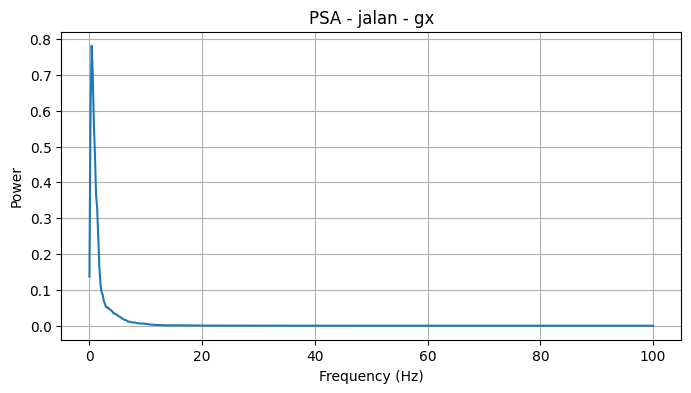

gy -> Dominant Freq = 0.391 Hz | Power = 0.75866


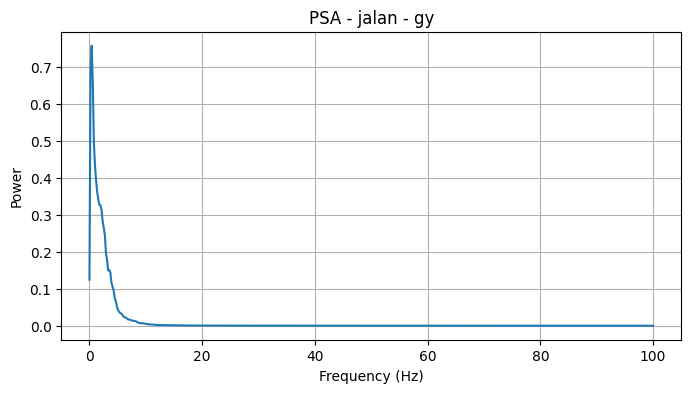

gz -> Dominant Freq = 0.781 Hz | Power = 1.16869


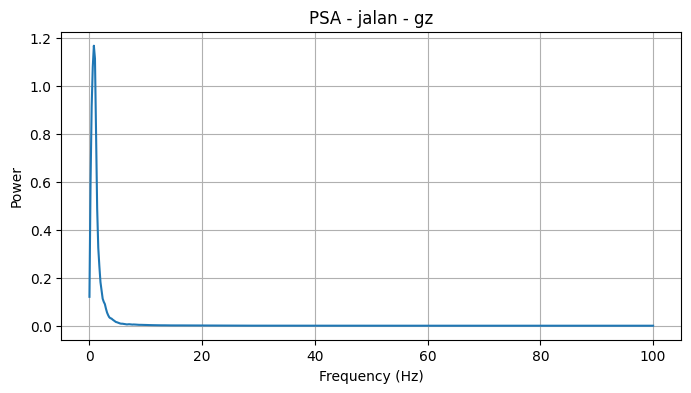


KELAS : diamjatuh
Jumlah Window : 957
ax -> Dominant Freq = 0.195 Hz | Power = 1.08587


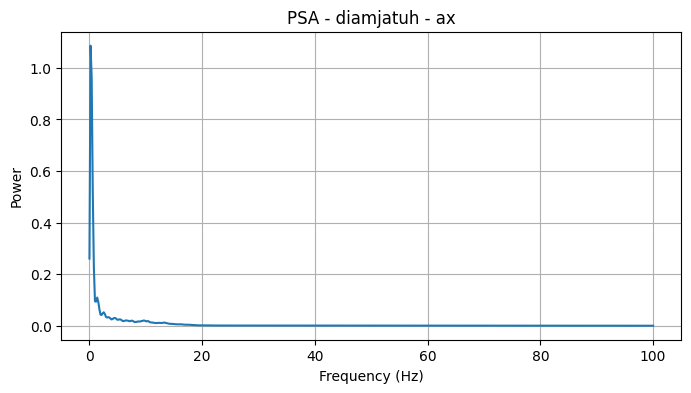

ay -> Dominant Freq = 0.195 Hz | Power = 1.38098


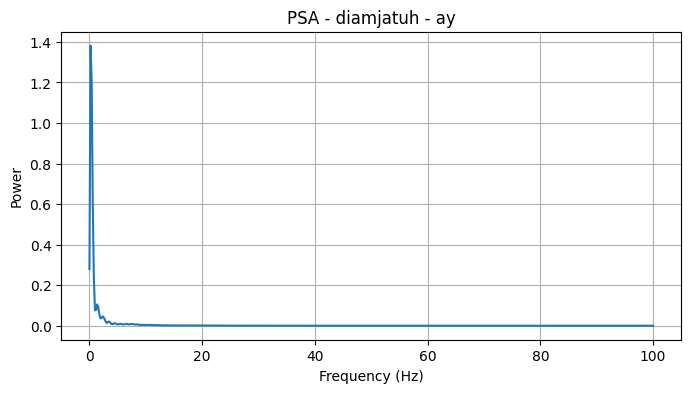

az -> Dominant Freq = 0.195 Hz | Power = 1.53533


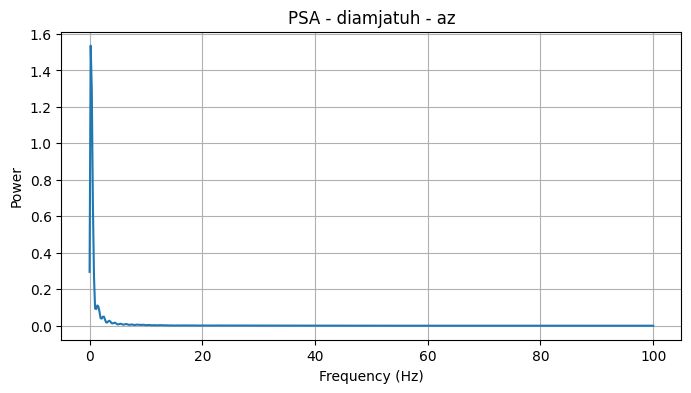

gx -> Dominant Freq = 0.586 Hz | Power = 0.30653


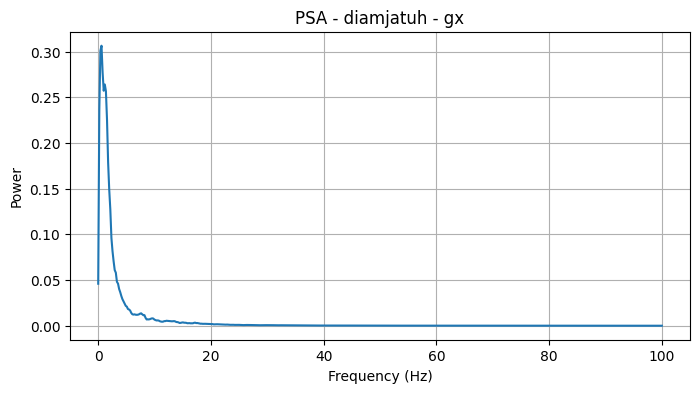

gy -> Dominant Freq = 0.391 Hz | Power = 0.23157


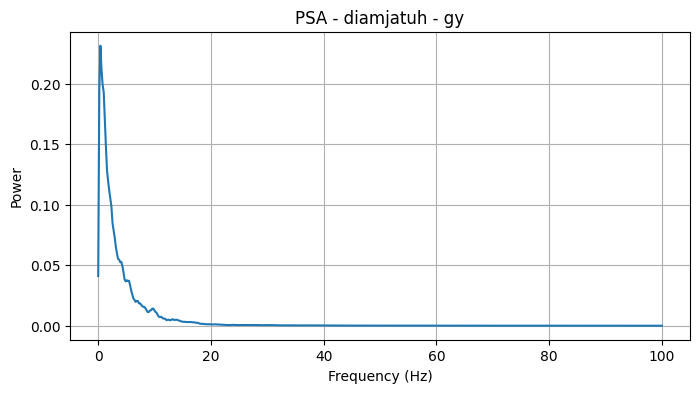

gz -> Dominant Freq = 0.391 Hz | Power = 0.19591


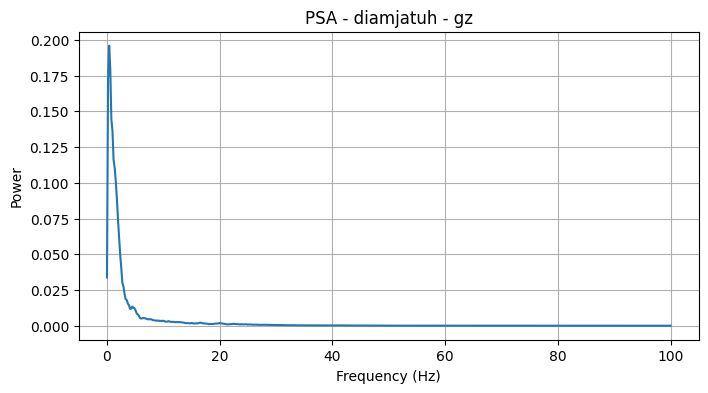


KELAS : jalanjatuh
Jumlah Window : 958
ax -> Dominant Freq = 0.195 Hz | Power = 1.39254


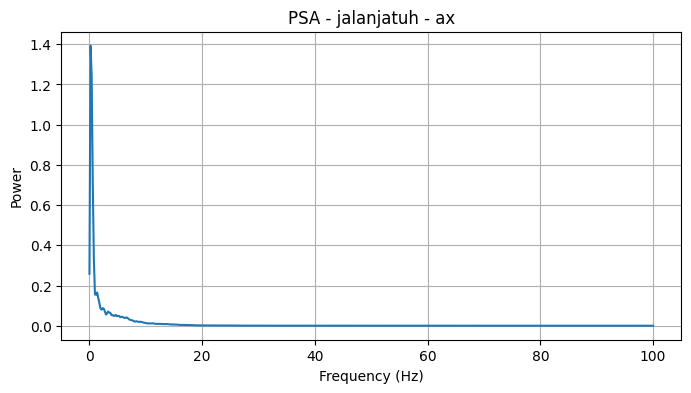

ay -> Dominant Freq = 0.195 Hz | Power = 1.06462


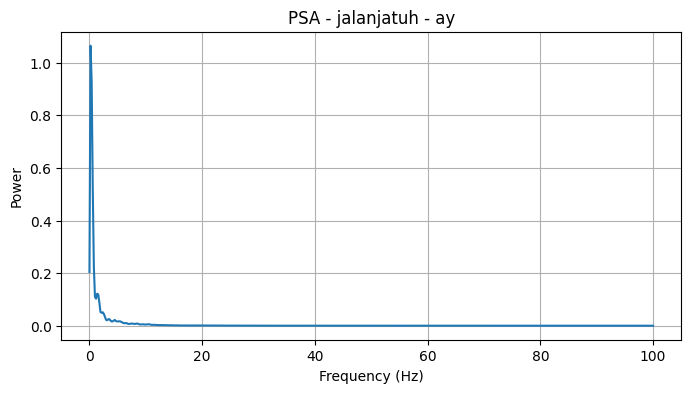

az -> Dominant Freq = 0.195 Hz | Power = 0.84187


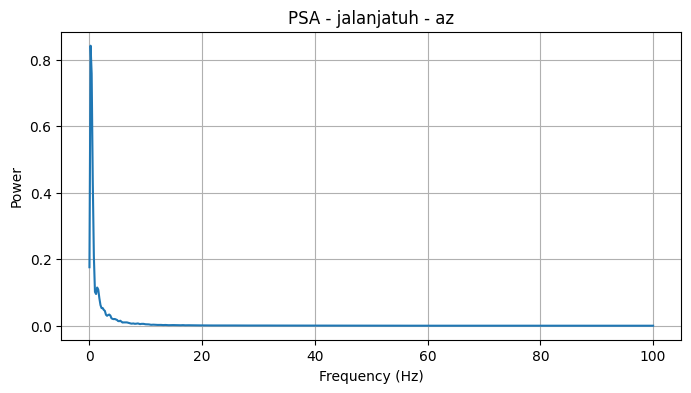

gx -> Dominant Freq = 0.781 Hz | Power = 0.83658


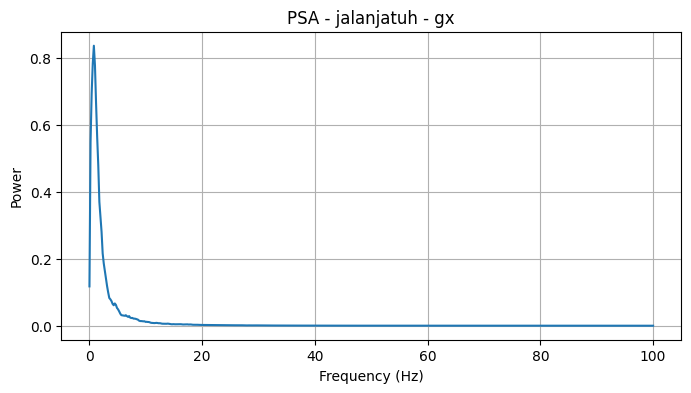

gy -> Dominant Freq = 0.391 Hz | Power = 0.55903


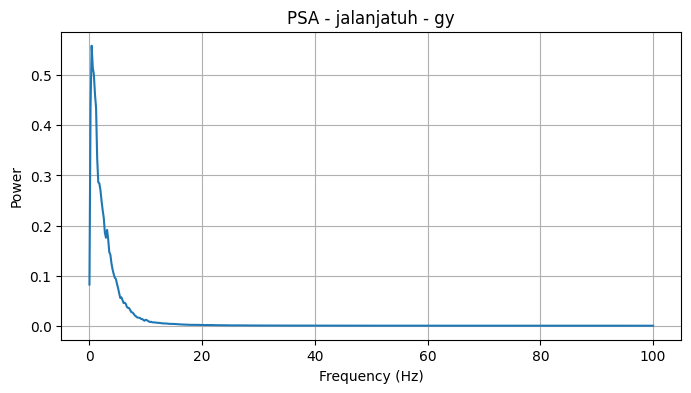

gz -> Dominant Freq = 0.781 Hz | Power = 1.24567


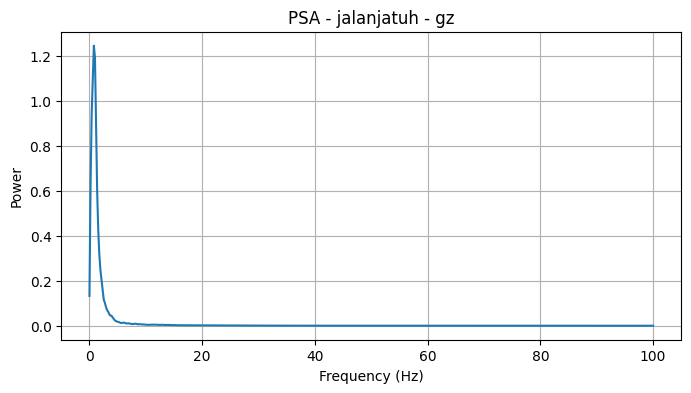

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# LOAD DATASET HASIL WINDOWING

path = "/content/drive/My Drive/Colab Notebooks/datasetready_200_overlap75/"

X_train = np.load(path + "X_train.npy")
y_train = np.load(path + "y_train.npy")

print("Shape X_train :", X_train.shape)
print("Shape y_train :", y_train.shape)

# NAMA KELAS

kelas_nama = {
    0: "diam",
    1: "jalan",
    2: "diamjatuh",
    3: "jalanjatuh"
}

# NAMA FITUR

fitur = [
    "ax",
    "ay",
    "az",
    "gx",
    "gy",
    "gz"
]

# SAMPLING RATE

fs = 200

# PSA PER KELAS

for label in range(4):

    print("\nKELAS :", kelas_nama[label])

    # ambil semua window dari kelas tertentu
    data_kelas = X_train[y_train == label]

    print("Jumlah Window :", data_kelas.shape[0])

    # gabungkan semua window menjadi sinyal panjang
    # shape awal:
    # (jumlah_window, 200, 6)

    data_merge = data_kelas.reshape(-1, 6)

    # plot PSA tiap fitur

    for i in range(6):

        signal = data_merge[:, i]

        # WELCH PSD
        freq, power = welch(
            signal,
            fs=fs,
            nperseg=1024
        )

        # dominant frequency
        idx = np.argmax(power)

        dom_freq = freq[idx]
        dom_power = power[idx]

        print(
            fitur[i],
            "-> Dominant Freq =",
            round(dom_freq,3),
            "Hz | Power =",
            round(dom_power,5)
        )

        # PLOT
        plt.figure(figsize=(8,4))

        plt.plot(freq, power)

        plt.title(
            "PSA - " +
            kelas_nama[label] +
            " - " +
            fitur[i]
        )

        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power")

        plt.grid(True)

        plt.show()